# Plotting OLS vs Cor results of SEACElls

In [1]:
#read in the results from correlation analysis, then aggregate
import pandas as pd

cor_res_100kb = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Correlations/Results/gene_peak_correlation_sc_100kb_results.csv")
cor_res_100kb.head() 

# classify every peak–gene pair into one of three categories
def classify_pair(row):
    if row["padj"] <= 0.05 and row["correlation"] < 0:
        return "sig. negative"
    elif row["padj"] <= 0.05 and row["correlation"] > 0:
        return "sig. positive"
    else:
        return "non-significant"

cor_res_100kb["category"] = cor_res_100kb.apply(classify_pair, axis=1)

#aggregate the number of significant peaks per gene and category  
agg_cor_100kb_df = (
    cor_res_100kb
    .dropna(subset=["correlation", "padj", "category"])
    .groupby(["window", "gene", "category"])
    .size()
    .reset_index(name="count")
)
agg_cor_100kb_df.head()

,window,gene,category,count
0,100kb,a1cf,non-significant,38
1,100kb,a1cf,sig. positive,57
2,100kb,a2ml,non-significant,35
3,100kb,a2ml,sig. positive,42
4,100kb,aaas,non-significant,19


In [2]:
#read in the saved all_ols_dfs dataframe to confirm it was saved correctly
ols_res_100kb = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/OLS/Results/ols_results_100kb_df_sc.csv")
ols_res_100kb.head()

#aggregate the number of significant peaks per gene and category for OLS results
agg_ols_100kb_df = (
    ols_res_100kb
    .dropna(subset=["pval", "coef", "category"])
    .groupby(["window", "gene", "category"]) 
    .size()
    .reset_index(name="count")
)
agg_ols_100kb_df.head()

,window,gene,category,count
0,100kb,a1cf,non-significant,90
1,100kb,a1cf,sig. negative,3
2,100kb,a1cf,sig. positive,2
3,100kb,a2ml,non-significant,74
4,100kb,a2ml,sig. negative,1


In [3]:
#merge the two aggregated dataframes on window, gene to compare the number of significant peaks per gene and category between correlation and OLS results
agg_merged_df = pd.merge(
    agg_cor_100kb_df,
    agg_ols_100kb_df,
    on=["window", "gene", "category"],
    how="outer",
    suffixes=("_cor", "_ols") #add suffixes to distinguish between the two counts in the merged dataframe
)
agg_merged_df.head() 

,window,gene,category,count_cor,count_ols
0,100kb,a1cf,non-significant,38.0,90.0
1,100kb,a1cf,sig. negative,NaN,3.0
2,100kb,a1cf,sig. positive,57.0,2.0
3,100kb,a2ml,non-significant,35.0,74.0
4,100kb,a2ml,sig. negative,NaN,1.0


In [4]:
# Check if any gene appears more than once per window/category

plot_df = agg_merged_df.dropna(subset=["count_cor", "count_ols", "window", "category", "gene"]).copy()
plot_sig_df = plot_df[plot_df["category"] != "non-significant"].copy()

dups = (
    plot_sig_df
    .groupby(["gene", "window", "category"])
    .size()
    .reset_index(name="n_rows")
)
print(dups[dups["n_rows"] > 1])

Empty DataFrame
Columns: [gene, window, category, n_rows]
Index: []


/tmp/ipykernel_1119130/1194827368.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_sig_df["n_genes"] = plot_sig_df.groupby(


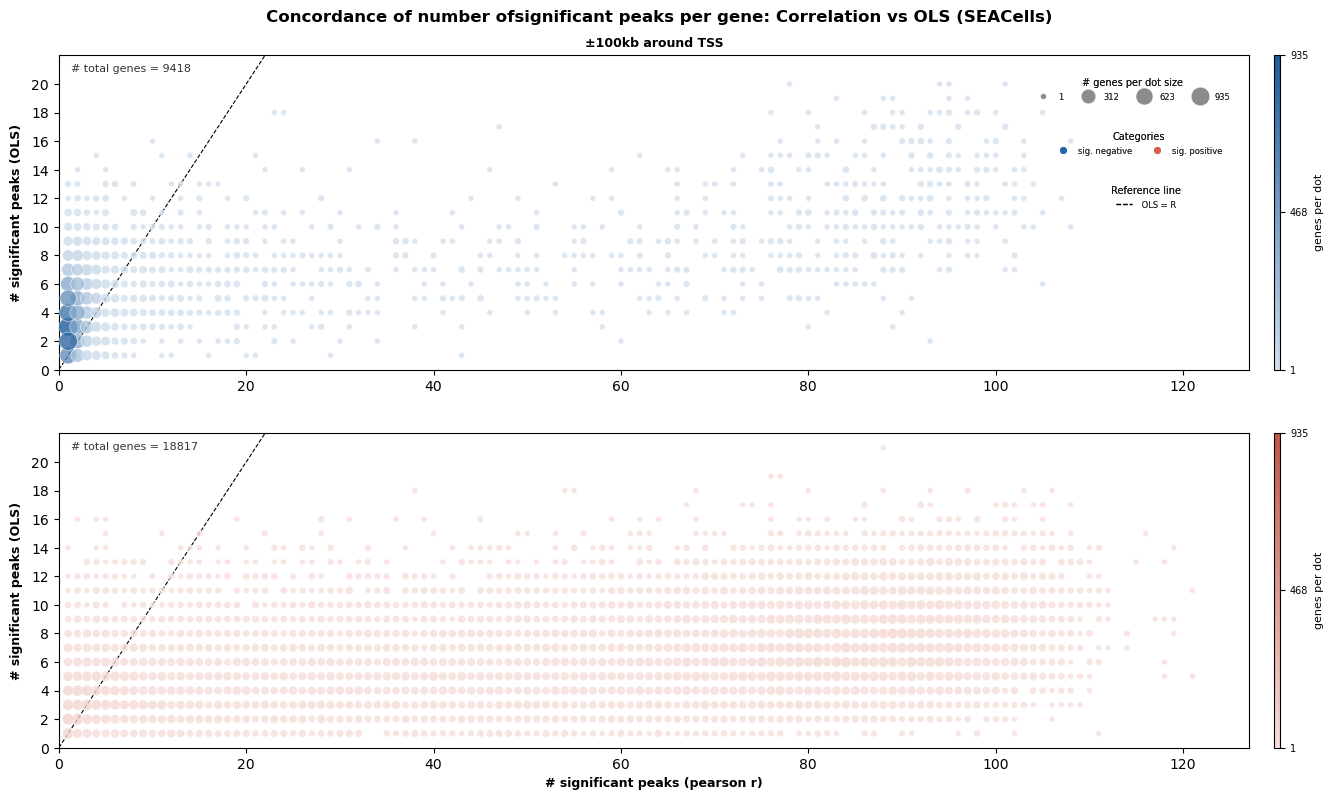

In [ ]:
#plot the number of significant peaks per gene in correlation vs OLS results, colored by category and faceted by window & category
from tkinter import font

from matplotlib.lines import Line2D
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

plot_df = agg_merged_df.dropna(subset=["count_cor", "count_ols", "window", "category", "gene"]).copy()
plot_df["window"] = pd.Categorical(
    plot_df["window"], categories=["100kb"], ordered=True,
)
plot_df["category"] = pd.Categorical(
    plot_df["category"],
    categories=["sig. negative", "non-significant", "sig. positive"], ordered=True,
)

plot_sig_df = plot_df[plot_df["category"] != "non-significant"].copy()

# Count genes per (count_cor, count_ols, window, category) position
plot_sig_df["n_genes"] = plot_sig_df.groupby(
    ["window", "category", "count_cor", "count_ols"] 
)["gene"].transform("count")

category_base_colors = {
    "sig. negative": "#2166ac",
    "sig. positive": "#d6604d",
}
category_order = ["sig. negative", "sig. positive"]
windows = ["100kb"]

# Deduplicate to one row per unique (x, y, window, category) position
plot_dedup = plot_sig_df.drop_duplicates(
    subset=["count_cor", "count_ols", "window", "category"]
).copy()

# Global n_genes range for consistent size/color scaling
n_min = plot_dedup["n_genes"].min()
n_max = plot_dedup["n_genes"].max()

def make_alpha_cmap(hex_color):
    r, g, b = mcolors.to_rgb(hex_color)
    light = (1 - (1 - r) * 0.20, 1 - (1 - g) * 0.20, 1 - (1 - b) * 0.20)
    dark  = (r * 0.9, g * 0.9, b * 0.9)
    return mcolors.LinearSegmentedColormap.from_list("cat_cmap", [light, dark])
# ↑ removed hex_color midpoint — now light=n_min, dark=n_max, linear between them
def size_scale(n, n_min, n_max, s_min=18, s_max=180):
    """Map gene count to marker area (sqrt scaling feels more linear visually)."""
    if n_max == n_min:
        return (s_min + s_max) / 2
    return s_min + (s_max - s_min) * ((n - n_min) / (n_max - n_min)) ** 0.5
# plot: rows = categories, cols = windows, points colored by category 
fig, axes = plt.subplots(
    len(category_order), len(windows),
    figsize=(16, 9),
    sharex=False, sharey=True,
)

axis_max = plot_dedup[["count_cor", "count_ols"]].max().max() 

for row_i, category in enumerate(category_order):
    cmap = make_alpha_cmap(category_base_colors[category])
    norm = Normalize(vmin=n_min, vmax=n_max) 
     # ✓ one colorbar per row, attached to the rightmost axis
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(
        sm,
        ax=axes[row_i],   # spans all axes in this row
        orientation="vertical",
        fraction=0.02,        # thin bar
        pad=0.02,
        aspect=50,
    )
    cbar.set_label("genes per dot", fontsize=8)
    cbar.ax.tick_params(labelsize=7)
    # tick at n_min, midpoint, n_max
    cbar.set_ticks([n_min, (n_min + n_max) // 2, n_max])

    for col_i, window in enumerate(windows):
        ax = axes[row_i]
        data = plot_dedup[
            (plot_dedup["window"] == window) &
            (plot_dedup["category"] == category)
        ]

        if not data.empty:
            sizes  = data["n_genes"].apply(lambda n: size_scale(n, n_min, n_max))
            colors = cmap(norm(data["n_genes"]))

            ax.scatter(
                data["count_cor"], data["count_ols"],
                c=colors, s = sizes,
                edgecolors="w", linewidths=0.4, zorder=3, alpha =0.8, 
            )

        ax.plot([0, axis_max], [0, axis_max],
                color="k", linestyle="--", linewidth=0.8, zorder=0)
        ax.set_xlim(0, axis_max*1.05)
        ax.set_ylim(0, plot_dedup[ "count_ols"].max()*1.05)

        if row_i == 0:
            ax.set_title("±100kb around TSS", fontsize=9, fontweight="bold")
        if col_i == 0:
            ax.set_ylabel("# significant peaks (OLS)", fontsize=9, labelpad=6,fontweight="bold")
        else:
            ax.set_ylabel("")
        if row_i == len(category_order) - 1:
            ax.set_xlabel("# significant peaks (pearson r)", fontsize=9,fontweight="bold")
        else:
            ax.set_xlabel("")

        n_total = data["n_genes"].sum()
        ax.text(0.01,0.97, f"# total genes = {n_total}", transform=ax.transAxes,
                ha="left", va="top", fontsize=8, color="0.2") #on the right side to avoid overlap with y-axis
        
# ── Legend: size scale (two columns) ────────────────────────────────────────────
legend_counts = np.linspace(n_min, n_max, 4).astype(int)

size_handles = [
    Line2D([0], [0], marker="o", linestyle="",
           markersize=np.sqrt(size_scale(n, n_min, n_max)),
           markerfacecolor="0.55", markeredgecolor="w", markeredgewidth=0.4,
           label=str(n))
    for n in legend_counts
]

size_legend = fig.legend(
    handles=size_handles,
    title="# genes per dot size",
    loc="lower right",
    bbox_to_anchor=(0.862, 0.82),
    ncol= 4,
    frameon=False,
    fontsize=6,
    title_fontsize=7,
)

# bold + center the size legend's title (it's a separate Text object, easier to control)
size_legend.get_title().set_fontweight("roman")
size_legend.get_title().set_color("0.1")
size_legend.get_title().set_ha("center")
for text in size_legend.get_texts():
    text.set_color("0.2")
# ── Legend: categories ─────────────────────────────────────────────────────────
category_handles = [
    Line2D([0], [0], marker="o", linestyle="",
           markerfacecolor=category_base_colors[c],
           markeredgecolor=category_base_colors[c],
           markersize=4, label=c)
    for c in category_order
]

cat_legend = fig.legend(
    handles=category_handles,
    title="Categories",
    loc="lower right",
    bbox_to_anchor=(0.857, 0.76),
    ncol=2,
    frameon=False,
    fontsize=6,
    title_fontsize=7,
)
# bold + center the cat legend's title (it's a separate Text object, easier to control)
cat_legend.get_title().set_fontweight("roman")
cat_legend.get_title().set_ha("center")
cat_legend.get_title().set_color("0.1")
for text in cat_legend.get_texts():
    text.set_color("0.2")


# ── Legend: diagonal line ─────────────────────────────────────────────────────
line_handle = [
    Line2D([0], [0], color="k", linestyle="--", linewidth=0.9, label=" OLS = R")
]

line_legend = fig.legend(
    handles=line_handle,
    title="Reference line",
    loc="lower right",
    bbox_to_anchor=(0.831, 0.7),
    frameon=False,
    fontsize=6,
    title_fontsize=7,
)
# bold + center the size legend's title (it's a separate Text object, easier to control)
line_legend.get_title().set_fontweight("roman")
line_legend.get_title().set_color("0.1")
line_legend.get_title().set_ha("center")
for text in line_legend.get_texts():
    text.set_color("0.2")

fig.add_artist(cat_legend)  # ensure both persist (fig.legend can overwrite the previous one's reference internally in some mpl versions)
fig.add_artist(size_legend)  # ensure both persist (fig.legend can overwrite the previous one's reference internally in some mpl versions)
fig.add_artist(line_legend)  # ensure both persist (fig.legend can overwrite the previous one's reference internally in some mpl versions)

plt.yticks(np.arange(0, plot_dedup[ "count_ols"].max()+ 1, 2))
plt.suptitle(
    "Concordance of number ofsignificant peaks per gene: Correlation vs OLS (SEACells)",
    fontsize=12, y= 0.93, fontweight="bold",
)

plt.show()



/tmp/ipykernel_1119130/2072881570.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["window", "category"])["gene"]


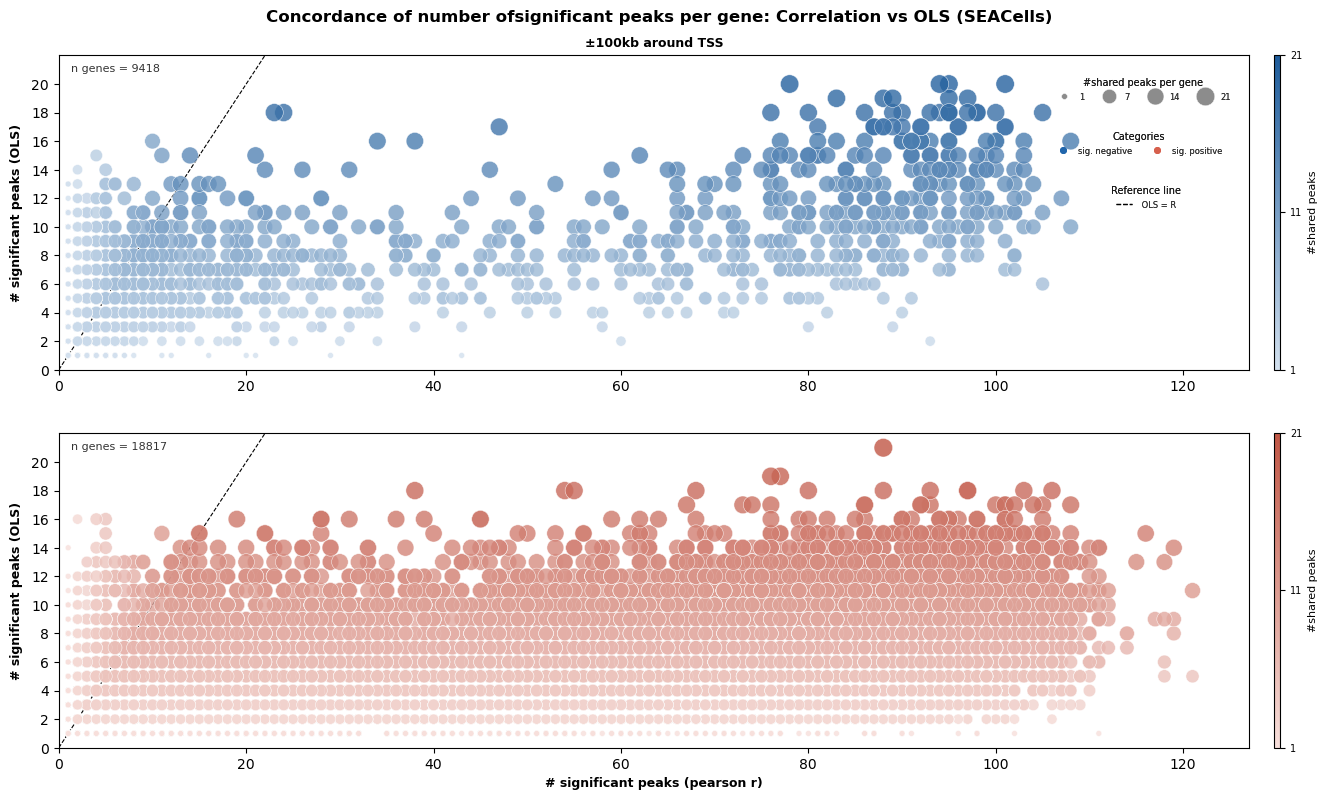

In [6]:
#plot the number of significant peaks per gene in correlation vs OLS results, colored by category and faceted by window & category
from tkinter import font

from matplotlib.lines import Line2D
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

plot_df = agg_merged_df.dropna(subset=["count_cor", "count_ols", "window", "category", "gene"]).copy()
plot_df["window"] = pd.Categorical(
    plot_df["window"], categories=["100kb"], ordered=True,
)
plot_df["category"] = pd.Categorical(
    plot_df["category"],
    categories=["sig. negative", "non-significant", "sig. positive"], ordered=True,
)

plot_sig_df = plot_df[plot_df["category"] != "non-significant"].copy()

category_base_colors = {
    "sig. negative": "#2166ac",
    "sig. positive": "#d6604d",
}
category_order = ["sig. negative", "sig. positive"]
windows = ["100kb"]

# Shared peaks between methods per gene
plot_sig_df["count_shared"] = plot_sig_df[["count_cor", "count_ols"]].min(axis=1)

# Deduplicate to one row per gene, window, category
plot_dedup = plot_sig_df.drop_duplicates(
    subset=["gene", "window", "category"]
).copy()

# Gene counts per category/window
gene_counts = (
    plot_dedup
    .groupby(["window", "category"])["gene"]
    .nunique()
    .reset_index()
    .rename(columns={"gene": "n_genes_unique"})
)

# Scaling based on shared peaks
n_min = plot_dedup["count_shared"].min()
n_max = plot_dedup["count_shared"].max()

def make_alpha_cmap(hex_color):
    r, g, b = mcolors.to_rgb(hex_color)
    light = (1 - (1 - r) * 0.20, 1 - (1 - g) * 0.20, 1 - (1 - b) * 0.20)
    dark  = (r * 0.9, g * 0.9, b * 0.9)
    return mcolors.LinearSegmentedColormap.from_list("cat_cmap", [light, dark])
# ↑ removed hex_color midpoint — now light=n_min, dark=n_max, linear between them

def size_scale(n, n_min, n_max, s_min=18, s_max=180):
    if n_max == n_min:
        return (s_min + s_max) / 2
    return s_min + (s_max - s_min) * ((n - n_min) / (n_max - n_min)) ** 0.5
# plot: rows = categories, cols = windows, points colored by category 
fig, axes = plt.subplots(
    len(category_order), len(windows),
    figsize=(16, 9),
    sharex=False, sharey=True,
)

axis_max = plot_dedup[["count_cor", "count_ols"]].max().max() 

for row_i, category in enumerate(category_order):
    cmap = make_alpha_cmap(category_base_colors[category])
    norm = Normalize(vmin=n_min, vmax=n_max) 
     # ✓ one colorbar per row, attached to the rightmost axis
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(
        sm,
        ax=axes[row_i],   # spans all axes in this row
        orientation="vertical",
        fraction=0.02,        # thin bar
        pad=0.02,
        aspect=50,
    )
    cbar.set_label("#shared peaks", fontsize=8)
    cbar.ax.tick_params(labelsize=7)
    # tick at n_min, midpoint, n_max
    cbar.set_ticks([n_min, (n_min + n_max) // 2, n_max])

    for col_i, window in enumerate(windows):
        ax = axes[row_i]
        data = plot_dedup[
            (plot_dedup["window"] == window) &
            (plot_dedup["category"] == category)
        ]

        if not data.empty:
            sizes  = data["count_shared"].apply(lambda n: size_scale(n, n_min, n_max))
            colors = cmap(norm(data["count_shared"]))

            ax.scatter(
                data["count_cor"], data["count_ols"],
                c=colors, s = sizes,
                edgecolors="w", linewidths=0.4, zorder=3, alpha =0.8, 
            )

        ax.plot([0, axis_max], [0, axis_max],
                color="k", linestyle="--", linewidth=0.8, zorder=0)
        ax.set_xlim(0, axis_max*1.05)
        ax.set_ylim(0, plot_dedup[ "count_ols"].max()*1.05)

        if row_i == 0:
            ax.set_title("±100kb around TSS", fontsize=9, fontweight="bold")
        if col_i == 0:
            ax.set_ylabel("# significant peaks (OLS)", fontsize=9, labelpad=6,fontweight="bold")
        else:
            ax.set_ylabel("")
        if row_i == len(category_order) - 1:
            ax.set_xlabel("# significant peaks (pearson r)", fontsize=9,fontweight="bold")
        else:
            ax.set_xlabel("")

        #gene counts per category/window
        n_genes_cat = gene_counts.loc[
            (gene_counts["window"] == window) &
            (gene_counts["category"] == category),
            "n_genes_unique"
        ].values
        n_genes_cat = n_genes_cat[0] if len(n_genes_cat) > 0 else 0

        ax.text(
            0.01, 0.97,
            f"n genes = {n_genes_cat}",
            transform=ax.transAxes,
            ha="left", va="top", fontsize=8, color="0.2"
        )
        
# ── Legend: size scale (two columns) ────────────────────────────────────────────
legend_counts = np.linspace(n_min, n_max, 4).astype(int)

size_handles = [
    Line2D([0], [0], marker="o", linestyle="",
           markersize=np.sqrt(size_scale(n, n_min, n_max)),
           markerfacecolor="0.55", markeredgecolor="w", markeredgewidth=0.4,
           label=str(n))
    for n in legend_counts
]

size_legend = fig.legend(
    handles=size_handles,
    title="#shared peaks per gene",
    loc="lower right",
    bbox_to_anchor=(0.862, 0.82),
    ncol= 4,
    frameon=False,
    fontsize=6,
    title_fontsize=7,
)

# bold + center the size legend's title (it's a separate Text object, easier to control)
size_legend.get_title().set_fontweight("roman")
size_legend.get_title().set_color("0.1")
size_legend.get_title().set_ha("center")
for text in size_legend.get_texts():
    text.set_color("0.2")
# ── Legend: categories ─────────────────────────────────────────────────────────
category_handles = [
    Line2D([0], [0], marker="o", linestyle="",
           markerfacecolor=category_base_colors[c],
           markeredgecolor=category_base_colors[c],
           markersize=4, label=c)
    for c in category_order
]

cat_legend = fig.legend(
    handles=category_handles,
    title="Categories",
    loc="lower right",
    bbox_to_anchor=(0.857, 0.76),
    ncol=2,
    frameon=False,
    fontsize=6,
    title_fontsize=7,
)
# bold + center the cat legend's title (it's a separate Text object, easier to control)
cat_legend.get_title().set_fontweight("roman")
cat_legend.get_title().set_ha("center")
cat_legend.get_title().set_color("0.1")
for text in cat_legend.get_texts():
    text.set_color("0.2")


# ── Legend: diagonal line ─────────────────────────────────────────────────────
line_handle = [
    Line2D([0], [0], color="k", linestyle="--", linewidth=0.9, label=" OLS = R")
]

line_legend = fig.legend(
    handles=line_handle,
    title="Reference line",
    loc="lower right",
    bbox_to_anchor=(0.831, 0.7),
    frameon=False,
    fontsize=6,
    title_fontsize=7,
)
# bold + center the size legend's title (it's a separate Text object, easier to control)
line_legend.get_title().set_fontweight("roman")
line_legend.get_title().set_color("0.1")
line_legend.get_title().set_ha("center")
for text in line_legend.get_texts():
    text.set_color("0.2")

fig.add_artist(cat_legend)  # ensure both persist (fig.legend can overwrite the previous one's reference internally in some mpl versions)
fig.add_artist(size_legend)  # ensure both persist (fig.legend can overwrite the previous one's reference internally in some mpl versions)
fig.add_artist(line_legend)  # ensure both persist (fig.legend can overwrite the previous one's reference internally in some mpl versions)

plt.yticks(np.arange(0, plot_dedup[ "count_ols"].max()+ 1, 2))
plt.suptitle(
    "Concordance of number ofsignificant peaks per gene: Correlation vs OLS (SEACells)",
    fontsize=12, y= 0.93, fontweight="bold",
)

plt.show()



/tmp/ipykernel_1119130/1198117354.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_non_sig_df["n_genes"] = plot_non_sig_df.groupby(


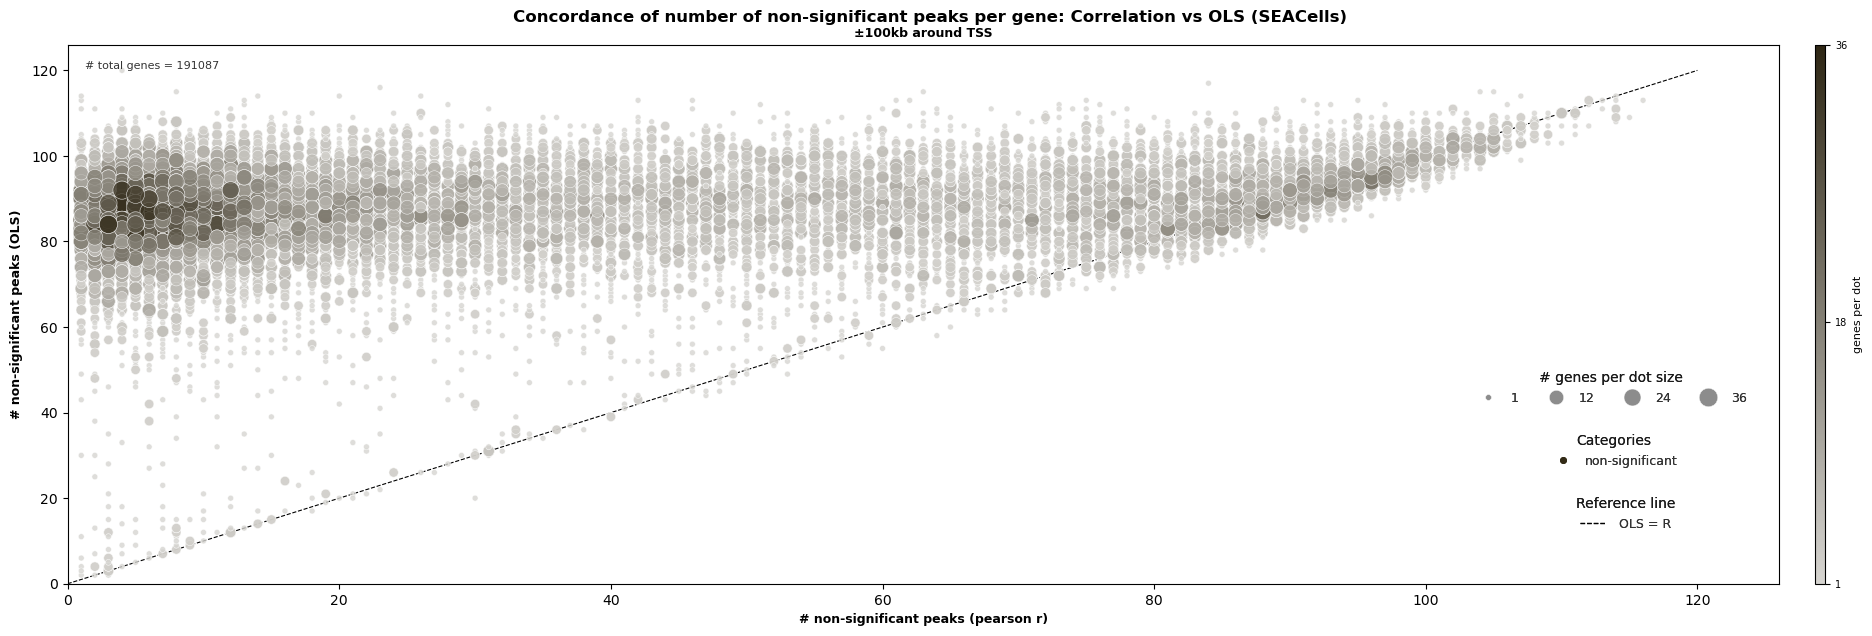

In [ ]:
#plot the number of significant peaks per gene in correlation vs OLS results, colored by category and faceted by window & category
from tkinter import font

from matplotlib.lines import Line2D
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

plot_df = agg_merged_df.dropna(subset=["count_cor", "count_ols", "window", "category", "gene"]).copy()
plot_df["window"] = pd.Categorical(
    plot_df["window"], categories=["100kb"], ordered=True,
)
plot_df["category"] = pd.Categorical(
    plot_df["category"],
    categories=["sig. negative", "non-significant", "sig. positive"], ordered=True,
)

plot_non_sig_df = plot_df[plot_df["category"] == "non-significant"].copy()

# Count genes per (count_cor, count_ols, window, category) position
plot_non_sig_df["n_genes"] = plot_non_sig_df.groupby(
    ["window", "category", "count_cor", "count_ols"] 
)["gene"].transform("count")

category_base_colors = {
    "non-significant": "#332b17",
}
category_order = ["non-significant"]
windows = ["100kb"]

# Deduplicate to one row per unique (x, y, window, category) position
plot_dedup = plot_non_sig_df.drop_duplicates(
    subset=["count_cor", "count_ols", "window", "category"]
).copy()

# Global n_genes range for consistent size/color scaling
n_min = plot_dedup["n_genes"].min()
n_max = plot_dedup["n_genes"].max()

def make_alpha_cmap(hex_color):
    r, g, b = mcolors.to_rgb(hex_color)
    light = (1 - (1 - r) * 0.20, 1 - (1 - g) * 0.20, 1 - (1 - b) * 0.20)
    dark  = (r * 0.9, g * 0.9, b * 0.9)
    return mcolors.LinearSegmentedColormap.from_list("cat_cmap", [light, dark])
# ↑ removed hex_color midpoint — now light=n_min, dark=n_max, linear between them
def size_scale(n, n_min, n_max, s_min=18, s_max=180):
    """Map gene count to marker area (sqrt scaling feels more linear visually)."""
    if n_max == n_min:
        return (s_min + s_max) / 2
    return s_min + (s_max - s_min) * ((n - n_min) / (n_max - n_min)) ** 0.5
# plot: rows = categories, cols = windows, points colored by category 
fig, axes = plt.subplots(
    len(category_order), len(windows),
    figsize=(23, 7),
    sharex=False, sharey=True,
)

axis_max = plot_dedup[["count_cor", "count_ols"]].max().max() 

for row_i, category in enumerate(category_order):
    cmap = make_alpha_cmap(category_base_colors[category])
    norm = Normalize(vmin=n_min, vmax=n_max) 
     # ✓ one colorbar per row, attached to the rightmost axis
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(
        sm,
        ax= axes,  # spans all axes in this row
        orientation="vertical",
        fraction=0.02,        # thin bar
        pad=0.02,
        aspect=50,
    )
    cbar.set_label("genes per dot", fontsize=8)
    cbar.ax.tick_params(labelsize=7)
    # tick at n_min, midpoint, n_max
    cbar.set_ticks([n_min, (n_min + n_max) // 2, n_max])

    for col_i, window in enumerate(windows):
        ax = axes
        data = plot_dedup[
            (plot_dedup["window"] == window) &
            (plot_dedup["category"] == category)
        ]

        if not data.empty:
            sizes  = data["n_genes"].apply(lambda n: size_scale(n, n_min, n_max))
            colors = cmap(norm(data["n_genes"]))

            ax.scatter(
                data["count_cor"], data["count_ols"],
                c=colors, s = sizes,
                edgecolors="w", linewidths=0.4, zorder=3, alpha =0.8, 
            )

        ax.plot([0, axis_max], [0, axis_max],
                color="k", linestyle="--", linewidth=0.8, zorder=0)
        ax.set_xlim(0, axis_max*1.05)
        ax.set_ylim(0, plot_dedup[ "count_ols"].max()*1.05)

        if row_i == 0:
            ax.set_title("±100kb around TSS", fontsize=9, fontweight="bold")
        if col_i == 0:
            ax.set_ylabel("# non-significant peaks (OLS)", fontsize=9, labelpad=6,fontweight="bold")
        else:
            ax.set_ylabel("")
        if row_i == len(category_order) - 1:
            ax.set_xlabel("# non-significant peaks (pearson r)", fontsize=9,fontweight="bold")
        else:
            ax.set_xlabel("")

        n_total = data["n_genes"].sum()
        ax.text(0.01,0.97, f"# total genes = {n_total}", transform=ax.transAxes,
                ha="left", va="top", fontsize=8, color="0.2") #on the right side to avoid overlap with y-axis
        
# ── Legend: size scale (two columns) ────────────────────────────────────────────
legend_counts = np.linspace(n_min, n_max, 4).astype(int)

size_handles = [
    Line2D([0], [0], marker="o", linestyle="",
           markersize=np.sqrt(size_scale(n, n_min, n_max)),
           markerfacecolor="0.55", markeredgecolor="w", markeredgewidth=0.4,
           label=str(n))
    for n in legend_counts
]

size_legend = fig.legend(
    handles=size_handles,
    title="# genes per dot size",
    loc="lower right",
    bbox_to_anchor=(0.86, 0.35),
    ncol= 4,
    frameon=False,
    fontsize=9,
    title_fontsize=10,
)

# bold + center the size legend's title (it's a separate Text object, easier to control)
size_legend.get_title().set_fontweight("roman")
size_legend.get_title().set_color("0.1")
size_legend.get_title().set_ha("center")
for text in size_legend.get_texts():
    text.set_color("0.2")
# ── Legend: categories ─────────────────────────────────────────────────────────
category_handles = [
    Line2D([0], [0], marker="o", linestyle="",
           markerfacecolor=category_base_colors[c],
           markeredgecolor=category_base_colors[c],
           markersize=4, label=c)
    for c in category_order
]

cat_legend = fig.legend(
    handles=category_handles,
    title="Categories",
    loc="lower right",
    bbox_to_anchor=(0.83, 0.26),
    ncol=2,
    frameon=False,
    fontsize=9,
    title_fontsize=10,
)
# bold + center the cat legend's title (it's a separate Text object, easier to control)
cat_legend.get_title().set_fontweight("roman")
cat_legend.get_title().set_ha("center")
cat_legend.get_title().set_color("0.1")
for text in cat_legend.get_texts():
    text.set_color("0.2")


# ── Legend: diagonal line ─────────────────────────────────────────────────────
line_handle = [
    Line2D([0], [0], color="k", linestyle="--", linewidth=0.9, label=" OLS = R")
]

line_legend = fig.legend(
    handles=line_handle,
    title="Reference line",
    loc="lower right",
    bbox_to_anchor=(0.829, 0.17),
    frameon=False,
    fontsize=9,
    title_fontsize=10,
)
# bold + center the size legend's title (it's a separate Text object, easier to control)
line_legend.get_title().set_fontweight("roman")
line_legend.get_title().set_color("0.1")
line_legend.get_title().set_ha("center")
for text in line_legend.get_texts():
    text.set_color("0.2")

fig.add_artist(cat_legend)  # ensure both persist (fig.legend can overwrite the previous one's reference internally in some mpl versions)
fig.add_artist(size_legend)  # ensure both persist (fig.legend can overwrite the previous one's reference internally in some mpl versions)
fig.add_artist(line_legend)  # ensure both persist (fig.legend can overwrite the previous one's reference internally in some mpl versions)

plt.suptitle(
    "Concordance of number of non-significant peaks per gene: Correlation vs OLS (SEACells)",
    fontsize=12, y= 0.93, fontweight="bold",
)

plt.show()

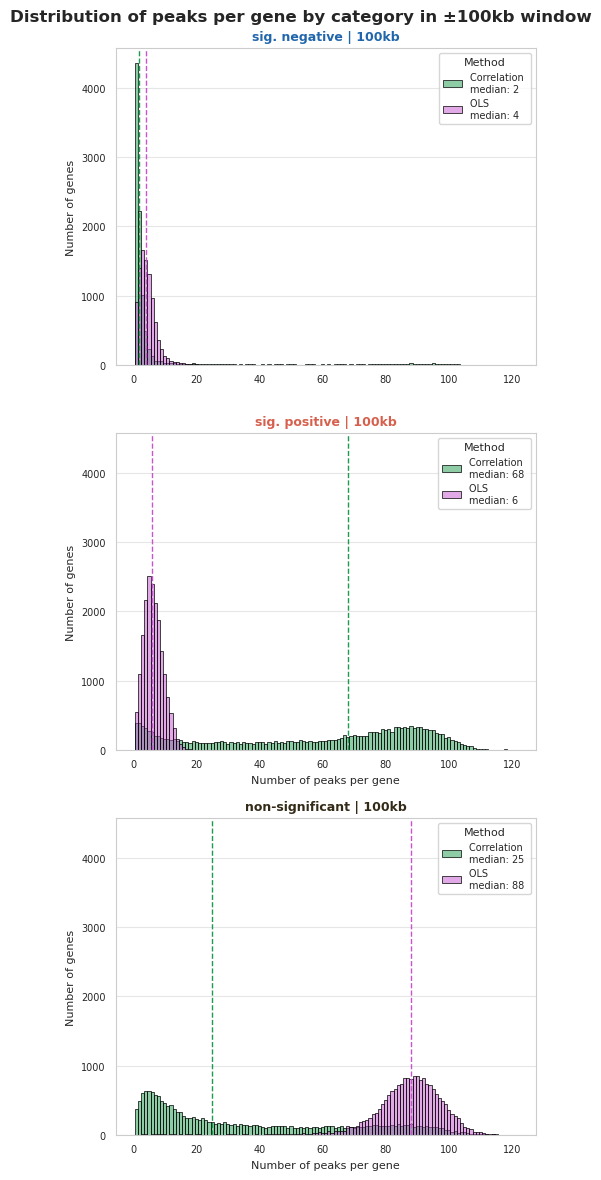

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid", {"axes.grid": True, "grid.color": ".9", "grid.linestyle": "-", "grid.linewidth": 0.5})
ax.grid(axis="x", visible=False)
plot_df = agg_merged_df.dropna(subset=["count_cor", "count_ols", "window", "category", "gene"]).copy()
plot_df["window"] = pd.Categorical(
    plot_df["window"], categories=["100kb"], ordered=True,
)
plot_df["category"] = pd.Categorical(
    plot_df["category"],
    categories=["sig. negative", "non-significant", "sig. positive"], ordered=True,
)

plot_sig_df = plot_df.copy()
plot_sig_df["category"] = pd.Categorical(
    plot_sig_df["category"],
    categories=["sig. negative", "sig. positive", "non-significant"],
    ordered=True,
)

#deduplicate to one row per unique (gene, window, category) position
plot_dedup = plot_sig_df.drop_duplicates(
    subset=["gene", "window", "category"]
).copy()

category_order = ["sig. negative", "sig. positive", "non-significant"]
category_base_colors = {
    "sig. negative": "#2166ac",
    "sig. positive": "#d6604d",
    "non-significant": "#332b17",
}
window_labels = ["100kb"]
method_colors = {"Correlation": "#1e9b4e", "OLS": "#c755d1"}

fig, axes = plt.subplots(len(category_order),1, figsize=(5, 12), sharex=True, sharey=True)


for row_idx, win in enumerate(window_labels):
    win_data = plot_dedup[plot_dedup["window"] == win]

    for col_idx, cat in enumerate(category_order):
        ax = axes[col_idx]
        cat_data = win_data[win_data["category"] == cat]

        combined_counts = pd.concat([win_data["count_cor"], win_data["count_ols"]]).dropna()
        if combined_counts.empty:
            ax.set_axis_off()
            continue
        
        #median values for each method
        median_cor = cat_data["count_cor"].median()
        median_ols = cat_data["count_ols"].median()

        bin_edges = np.linspace(combined_counts.min(), combined_counts.max(), 16)
        if np.unique(bin_edges).size < 2:
            bin_edges = np.array([combined_counts.min() - 0.5, combined_counts.max() + 0.5])

        # Plot correlation histogram
        sns.histplot(
            cat_data["count_cor"],
            #bins=bin_edges,
            alpha=0.5,
            label=f"Correlation \nmedian: {median_cor:.0f} ", 
            color=method_colors["Correlation"],
            edgecolor="black",
            linewidth=0.5,
            discrete=True,
            ax = ax

        )
        # Plot OLS histogram
        sns.histplot(
            cat_data["count_ols"],
            #bins=bin_edges,
            alpha=0.5,
            label=f"OLS \nmedian: {median_ols:.0f} ",
            color=method_colors["OLS"],
            edgecolor="black",
            linewidth=0.5,
            discrete=True,
            ax = ax
        )

        ax.set_xlabel("Number of peaks per gene", fontsize=8)
        ax.set_ylabel("Number of genes", fontsize=8)
        ax.set_title(f"{cat} | {win}", fontsize=9, fontweight="bold", color=category_base_colors.get(cat, "k"))
        ax.tick_params(labelsize=7)
        ax.legend(loc="upper right", fontsize=7, title="Method", title_fontsize=8, frameon=True)

#add median lines for each histogram
        median_cor = cat_data["count_cor"].median()
        median_ols = cat_data["count_ols"].median()
        ax.axvline(median_cor, color=method_colors["Correlation"], linestyle="--", linewidth=1)
        ax.axvline(median_ols, color=method_colors["OLS"], linestyle="--", linewidth=1)
        
        for ax in axes:
            ax.tick_params(axis='x', labelbottom=True)
            sns.set_style("whitegrid", {"axes.grid": True, "grid.color": ".9", "grid.linestyle": "-", "grid.linewidth": 0.5})
            ax.grid(axis="x", visible=False)
fig.suptitle("Distribution of peaks per gene by category in ±100kb window", fontsize=12, fontweight="bold", y=0.98)
fig.savefig("/home/fgsasse_lrs_1/Downloads/BA/BA_data/OLS/Results/peaks_per_gene_histogram.png", dpi=300)
plt.tight_layout()
plt.show()

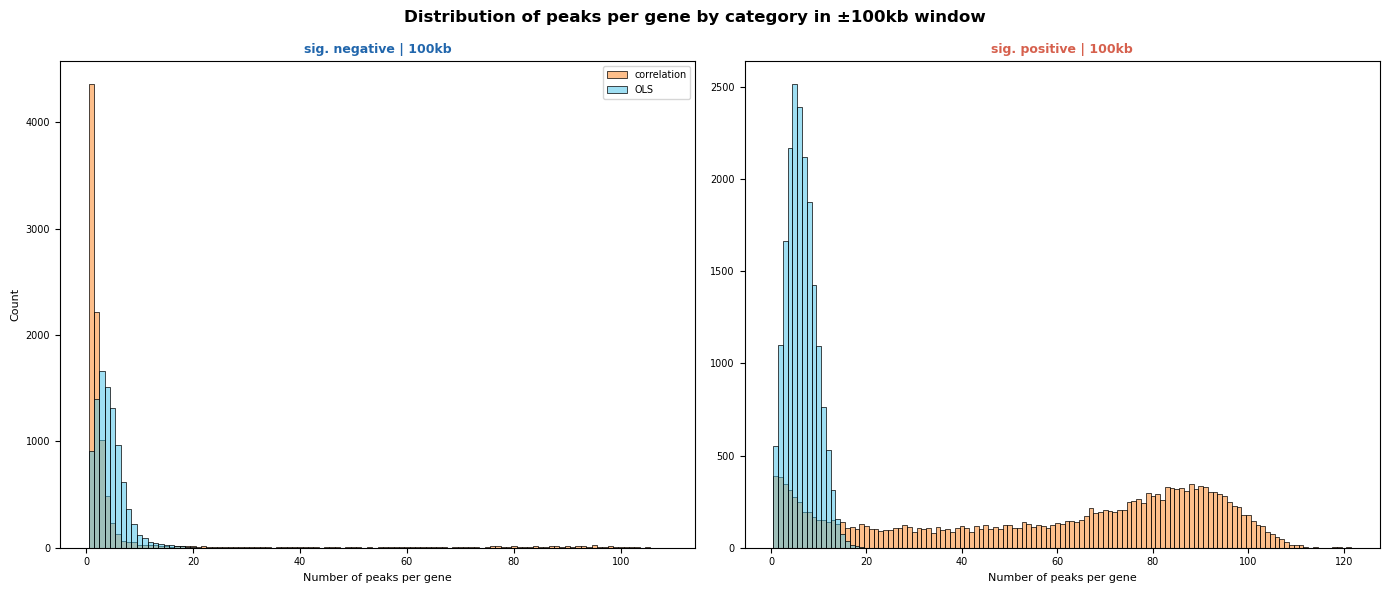

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = agg_merged_df.dropna(subset=["count_cor", "count_ols", "window", "category", "gene"]).copy()
plot_df["window"] = pd.Categorical(
    plot_df["window"], categories=["100kb"], ordered=True,
)
plot_df["category"] = pd.Categorical(
    plot_df["category"],
    categories=["sig. negative", "non-significant", "sig. positive"], ordered=True,
)

plot_sig_df = plot_df[plot_df["category"] != "non-significant"].copy()
plot_sig_df["category"] = pd.Categorical(
    plot_sig_df["category"],
    categories=["sig. negative", "sig. positive"],
    ordered=True,
)

# Deduplicate to one row per unique (x, y, window, category) position
plot_dedup = plot_sig_df.drop_duplicates(
    subset=["count_cor", "count_ols", "window", "category"]
).copy()
category_order = ["sig. negative", "sig. positive"]
window_labels = ["100kb"]
method_colors = {"correlation": "#fd7e16", "OLS": "#40c1e9"}

fig, axes = plt.subplots(len(window_labels),2, figsize=(14, 6), sharex=False, sharey=False)

for row_idx, win in enumerate(window_labels):
    win_data = plot_sig_df[plot_sig_df["window"] == win]

    for col_idx, cat in enumerate(category_order):
        ax = axes[col_idx]
        cat_data = win_data[win_data["category"] == cat]

        combined_counts = pd.concat([win_data["count_cor"], win_data["count_ols"]]).dropna()
        if combined_counts.empty:
            ax.set_axis_off()
            continue

        bin_edges = np.linspace(combined_counts.min(), combined_counts.max(), 16)
        if np.unique(bin_edges).size < 2:
            bin_edges = np.array([combined_counts.min() - 0.5, combined_counts.max() + 0.5])

        # Plot correlation histogram
        sns.histplot(
            cat_data["count_cor"],
            #bins=bin_edges,
            alpha=0.5,
            label="correlation",
            color=method_colors["correlation"],
            edgecolor="black",
            linewidth=0.5,
            discrete=True,
            ax = ax

        )
        # Plot OLS histogram
        sns.histplot(
            cat_data["count_ols"],
            #bins=bin_edges,
            alpha=0.5,
            label="OLS",
            color=method_colors["OLS"],
            edgecolor="black",
            linewidth=0.5,
            discrete=True,
            ax = ax
        )

        ax.set_xlabel("Number of peaks per gene", fontsize=8)
        ax.set_ylabel("Count" if col_idx == 0 else "", fontsize=8)
        ax.set_title(f"{cat} | {win}", fontsize=9, fontweight="bold", color="#2166ac" if cat == "sig. negative" else "#d6604d")
        ax.tick_params(labelsize=7)

        if row_idx == 0 and col_idx == 0:
            ax.legend(loc="upper right", fontsize=7)

fig.suptitle("Distribution of peaks per gene by category in ±100kb window", fontsize=12, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()

In [74]:
#filter out the genes only with significant peaks, existing in both datasets
sig_cor_df_cor = cor_res_100kb[cor_res_100kb["category"].isin(["sig. negative", "sig. positive"])]
sig_cor_df_ols = ols_res_100kb[ols_res_100kb["category"].isin(["sig. negative", "sig. positive"])]

#creat a dictionary with the significant peaks for each gene 

significant_peaks_dict_cor = {}
for gene_id, group in sig_cor_df_cor.groupby("gene"):
    sig_peaks = group[group["category"].isin(["sig. negative", "sig. positive"])]["peak"].tolist()
    significant_peaks_dict_cor[gene_id] = sig_peaks

significant_peaks_dict_ols = {}
for gene_id, group in sig_cor_df_ols.groupby("gene"):
    sig_peaks = group[group["category"].isin(["sig. negative", "sig. positive"])]["peak"].tolist()
    significant_peaks_dict_ols[gene_id] = sig_peaks

print(next(iter(significant_peaks_dict_cor.items())))
print(next(iter(significant_peaks_dict_ols.items())))

#count the number of significant peaks for each gene in both dictionaries and store the counts in a new dataframe with columns gene, n_sig_peaks_cor, n_sig_peaks_ols
import pandas as pd
gene_counts = []
for gene in set(list(significant_peaks_dict_cor.keys()) + list(significant_peaks_dict_ols.keys())):
    n_sig_peaks_cor = len(significant_peaks_dict_cor.get(gene, []))
    n_sig_peaks_ols = len(significant_peaks_dict_ols.get(gene, []))
    gene_counts.append({
        "gene": gene,
        "n_sig_peaks_cor": n_sig_peaks_cor,
        "n_sig_peaks_ols": n_sig_peaks_ols
    })
gene_counts_df = pd.DataFrame(gene_counts)

print(gene_counts_df.head())

('a1cf', ['12-6186644-6187111', '12-6190483-6191143', '12-6225169-6226018', '12-6100792-6101473', '12-6163466-6163906', '12-6226949-6227335', '12-6266602-6267534', '12-6260921-6261335', '12-6201711-6202346', '12-6255500-6255954', '12-6211542-6212324', '12-6194740-6195637', '12-6188050-6188583', '12-6130915-6131954', '12-6106568-6107956', '12-6268971-6269807', '12-6205005-6206034', '12-6189006-6189540', '12-6249731-6249963', '12-6083390-6083867', '12-6248665-6249566', '12-6092663-6093342', '12-6242806-6243344', '12-6160813-6162647', '12-6078540-6079520', '12-6104623-6105500', '12-6182609-6183304', '12-6207799-6208138', '12-6220367-6221270', '12-6176521-6177141', '12-6155246-6157486', '12-6181654-6182495', '12-6257422-6258222', '12-6186318-6186534', '12-6135283-6136959', '12-6121261-6121874', '12-6164835-6165767', '12-6177594-6178380', '12-6197831-6198221', '12-6174866-6175973', '12-6270678-6270880', '12-6262721-6263344', '12-6143709-6144602', '12-6235029-6235627', '12-6273948-6274547', 

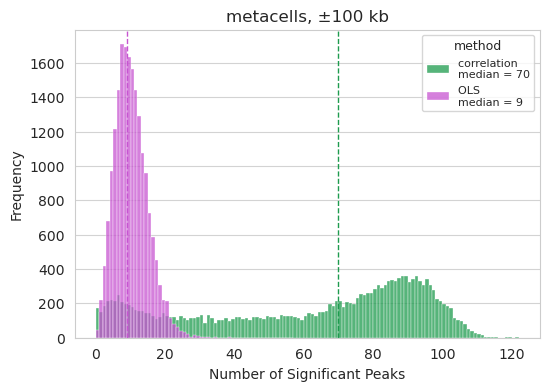

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

colors = ["#1e9b4e", "#c755d1"]  # ct + time, SEACells

# Compute medians
median_cor = gene_counts_df["n_sig_peaks_cor"].median()
median_ols = gene_counts_df["n_sig_peaks_ols"].median()

plt.figure(figsize=(6, 4))

sns.histplot(
    data=gene_counts_df,
    x="n_sig_peaks_cor",
    label=f"correlation \nmedian = {median_cor:.0f}",
    bins=range(0, gene_counts_df["n_sig_peaks_cor"].max() + 2),
    color=colors[0],
)

sns.histplot(
    data=gene_counts_df,
    x="n_sig_peaks_ols",
    label=f"OLS \nmedian = {median_ols:.0f}",
    bins=range(0, gene_counts_df["n_sig_peaks_ols"].max() + 2),
    color=colors[1],
)

# Optional: show median lines
plt.axvline(median_cor, color=colors[0], linestyle="--", linewidth=1)
plt.axvline(median_ols, color=colors[1], linestyle="--", linewidth=1)

sns.set_style("whitegrid", {
    'axes.grid': False,
    'grid.color': 'lightgray',
    'grid.linestyle': '-'
})

plt.grid(axis='y')
plt.xlabel("Number of Significant Peaks", fontsize=10)
plt.ylabel("Frequency", fontsize=10)
plt.title("metacells, ±100 kb")
plt.legend(title="method", title_fontsize=9, fontsize=8, loc="upper right", frameon=True)
plt.savefig("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Overlaps in resolution/Correlation/significant_peaks_histogram_100kb_sc.png", dpi=300, bbox_inches="tight")
plt.show()

# Gene annotation to genes in ols and cor results

In [5]:
#load the window_assignment_with_peak_counts_100kb.csv file to check if the new columns are there
import pandas as pd
window_assignment = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Overlaps OLS vs Cor/window_assignment_with_peak_counts_100kb.csv")
window_assignment.head()

#load the ols and correlation results dataframes
ols_100kb_df = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/OLS/Results/ols_results_100kb_df_sc.csv")
cor_100kb_df = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Correlations/Results/gene_peak_correlation_sc_100kb_results.csv")

In [6]:
print(ols_100kb_df.head())
print(cor_100kb_df.head())

  window  gene                peak      coef      pval         category
0  100kb  a1cf  12-6186644-6187111  0.021198  0.056007  non-significant
1  100kb  a1cf  12-6190483-6191143  0.018545  0.063436  non-significant
2  100kb  a1cf  12-6225169-6226018 -0.005018  0.621363  non-significant
3  100kb  a1cf  12-6114452-6114950 -0.001729  0.865097  non-significant
4  100kb  a1cf  12-6140521-6140735 -0.013947  0.155559  non-significant
  window  gene                peak  correlation    pvalue  neglog10_pvalue  \
0  100kb  a1cf  12-6186644-6187111     0.121149  0.000016         4.791006   
1  100kb  a1cf  12-6190483-6191143     0.117048  0.000031         4.506702   
2  100kb  a1cf  12-6225169-6226018     0.061143  0.029989         1.523041   
3  100kb  a1cf  12-6114452-6114950     0.060388  0.032080         1.493760   
4  100kb  a1cf  12-6140521-6140735     0.012429  0.659394         0.180855   

       padj  neglog10_padj  
0  0.000055       4.261565  
1  0.000099       4.004141  
2  0.048167 

In [7]:
# classify every peak–gene pair into one of three categories to cor results

def classify_pair(row):
    if row["padj"] <= 0.05 and row["correlation"] < 0:
        return "sig. negative"
    elif row["padj"] <= 0.05 and row["correlation"] > 0:
        return "sig. positive"
    else:
        return "non-significant"

cor_100kb_df["category"] = cor_100kb_df.apply(classify_pair, axis=1)
cor_100kb_df.head()

,window,gene,peak,correlation,pvalue,neglog10_pvalue,padj,neglog10_padj,category
0,100kb,a1cf,12-6186644-6187111,0.121149,0.000016,4.791006,0.000055,4.261565,sig. positive
1,100kb,a1cf,12-6190483-6191143,0.117048,0.000031,4.506702,0.000099,4.004141,sig. positive
2,100kb,a1cf,12-6225169-6226018,0.061143,0.029989,1.523041,0.048167,1.317250,sig. positive
3,100kb,a1cf,12-6114452-6114950,0.060388,0.032080,1.493760,0.051156,1.291101,non-significant
4,100kb,a1cf,12-6140521-6140735,0.012429,0.659394,0.180855,0.714356,0.146085,non-significant


In [9]:
#rename the window labels in the long format dataframes to be more descriptive
window_label_mapping = {
    '0-10': '0 < 10',
    '10-20': '10 < 20',
    '20-30': '20 < 30',
    '30-40': '30 < 40',
    '40-50': '40 < 50',
    '50-60': '50 < 60',
    '60-70': '60 < 70',
    '70-80': '70 < 80',
    '80-90': '80 < 90',
    '90-100': '90 < 100',
    '100-110': '100 < 110',
    '110-120': '110 < 120',
    '120-130': '120 < 130',
}

window_assignment["peak_count_window"] = window_assignment["peak_count_window"].replace(window_label_mapping)
window_assignment.head()

,gene_id,assigned_peaks,num_assigned_peaks,peak_count_window
0,a1cf,"[""['12-6186644-6187111'"", "" '12-6190483-619114...",95,90 < 100
1,a2ml,"[""['15-21143884-21144162'"", "" '15-21033797-210...",77,70 < 80
2,aaas,"[""['9-323370-323691'"", "" '9-209853-211311'"", ""...",110,100 < 110
3,aacs,"[""['5-18949828-18950713'"", "" '5-18811696-18812...",88,80 < 90
4,aadac,"[""['15-1052335-1053001'"", "" '15-1029184-103007...",100,90 < 100


add the window_assignment information to both dataframes by merging on gene_id

In [10]:
#rename window_assignment gene_id column to gene to match the cor_100kb_df dataframe
window_assignment = window_assignment.rename(columns={"gene_id": "gene"})

#merge on gene_id and assign the peak_count_window to the cor_100kb_df dataframe
cor_100kb_df = cor_100kb_df.merge(window_assignment[["gene", "peak_count_window"]], on="gene", how="left")
print(cor_100kb_df.head())

  window  gene                peak  correlation    pvalue  neglog10_pvalue  \
0  100kb  a1cf  12-6186644-6187111     0.121149  0.000016         4.791006   
1  100kb  a1cf  12-6190483-6191143     0.117048  0.000031         4.506702   
2  100kb  a1cf  12-6225169-6226018     0.061143  0.029989         1.523041   
3  100kb  a1cf  12-6114452-6114950     0.060388  0.032080         1.493760   
4  100kb  a1cf  12-6140521-6140735     0.012429  0.659394         0.180855   

       padj  neglog10_padj         category peak_count_window  
0  0.000055       4.261565    sig. positive          90 < 100  
1  0.000099       4.004141    sig. positive          90 < 100  
2  0.048167       1.317250    sig. positive          90 < 100  
3  0.051156       1.291101  non-significant          90 < 100  
4  0.714356       0.146085  non-significant          90 < 100  


In [11]:
#add the window_assignment information to the ols_100kb_df dataframe by merging on gene
ols_100kb_df = ols_100kb_df.merge(window_assignment[["gene", "peak_count_window"]], on="gene", how="left")
print(ols_100kb_df.head())

  window  gene                peak      coef      pval         category  \
0  100kb  a1cf  12-6186644-6187111  0.021198  0.056007  non-significant   
1  100kb  a1cf  12-6190483-6191143  0.018545  0.063436  non-significant   
2  100kb  a1cf  12-6225169-6226018 -0.005018  0.621363  non-significant   
3  100kb  a1cf  12-6114452-6114950 -0.001729  0.865097  non-significant   
4  100kb  a1cf  12-6140521-6140735 -0.013947  0.155559  non-significant   

  peak_count_window  
0          90 < 100  
1          90 < 100  
2          90 < 100  
3          90 < 100  
4          90 < 100  


In [12]:
#sort the dataframe by the peak_count_window column ascending
ols_100kb_df = ols_100kb_df.sort_values("peak_count_window")
cor_100kb_df = cor_100kb_df.sort_values("peak_count_window")
cor_100kb_df.head()

,window,gene,peak,correlation,pvalue,neglog10_pvalue,padj,neglog10_padj,category,peak_count_window
1326460,100kb,si:ch211-237a4.2,4-56495735-56496139,0.083681,2.952298e-03,2.529840,6.025340e-03,2.220018,sig. positive,0 < 10
1299714,100kb,si:ch211-141e20.2,9-19696386-19696788,0.099987,3.786092e-04,3.421809,9.469074e-04,3.023692,sig. positive,0 < 10
1299713,100kb,si:ch211-141e20.2,9-19813192-19813597,0.093182,9.277794e-04,3.032555,2.124966e-03,2.672648,sig. positive,0 < 10
1299712,100kb,si:ch211-141e20.2,9-19810800-19811101,0.149074,1.060336e-07,6.974557,5.716126e-07,6.242898,sig. positive,0 < 10
1299711,100kb,si:ch211-141e20.2,9-19730435-19731105,0.157053,2.093523e-08,7.679122,1.305814e-07,6.884119,sig. positive,0 < 10


In [13]:
window_labels = [window_assignment["peak_count_window"].sort_values().unique()]
window_labels

[array(['0 < 10', '10 < 20', '100 < 110', '110 < 120', '120 < 130',
        '20 < 30', '30 < 40', '40 < 50', '50 < 60', '60 < 70', '70 < 80',
        '80 < 90', '90 < 100'], dtype=object)]

Computing jaccard and retention score

In [14]:
#create a dictionary with the significant peaks for each gene for each peak_count_window, by filtering the results for significant peaks and grouping by gene and peak_count_window, and saving the significant peaks in a list for each gene and peak_count_window
window_labels = ['0 < 10', '10 < 20', '20 < 30', '30 < 40', '40 < 50', '50 < 60', '60 < 70', '70 < 80', '80 < 90', '90 < 100', '100 < 110', '110 < 120', '120 < 130']

sig_ols_df = ols_100kb_df[ols_100kb_df["category"].isin(["sig. negative", "sig. positive"])] 

sig_peaks_by_gene_ols = {} 

for window in window_labels:
    sig_peaks_by_gene_ols[window] = {}
    window_df = sig_ols_df[sig_ols_df["peak_count_window"] == window]
    for gene_id, group in window_df.groupby("gene"):
        sig_peaks_by_gene_ols[window][gene_id] = group["peak"].tolist()

In [17]:
print(next(iter(sig_peaks_by_gene_ols.items())))

('0 < 10', {'pimr156': ['13-9119700-9120029', '13-9244708-9244907', '13-9118986-9119219', '13-9137191-9137399', '13-9150354-9150640', '13-9205406-9205651', '13-9212805-9213146'], 'si:ch211-141e20.2': ['9-19730435-19731105', '9-19810800-19811101', '9-19696386-19696788', '9-19813955-19814167', '9-19818336-19818574'], 'si:ch211-207e19.2': ['4-56110786-56111229', '4-56090517-56091419'], 'si:ch211-227p7.1': ['4-56638846-56640646'], 'si:ch211-237a4.2': ['4-56495735-56496139', '4-56570953-56571184'], 'si:ch211-238e22.2': ['4-57113398-57113887', '4-57129423-57129824', '4-57091129-57091336'], 'si:ch211-238e22.4': ['4-57111440-57112008'], 'si:ch211-249c2.1': ['4-53927436-53928498', '4-53937600-53938300'], 'si:dkey-193i10.4': ['4-71240200-71240549', '4-71190865-71191269'], 'si:dkey-30f3.2': ['4-63739478-63739726', '4-63765015-63765385', '4-63894673-63895031', '4-63828897-63829351', '4-63827976-63828629'], 'si:dkey-51d8.1': ['4-45086861-45087320', '4-45085803-45086191'], 'si:dkey-57k17.1': ['4-579

In [15]:
#create a dictionary with the significant peaks for each gene for each peak_count_window, by filtering the results for significant peaks and grouping by gene and peak_count_window, and saving the significant peaks in a list for each gene and peak_count_window
sig_cor_df = cor_100kb_df[cor_100kb_df["category"].isin(["sig. negative", "sig. positive"])]
sig_peaks_by_gene_cor = {}
for window in window_labels:
    sig_peaks_by_gene_cor[window] = {}
    window_df = sig_cor_df[sig_cor_df["peak_count_window"] == window]
    for gene_id, group in window_df.groupby("gene"):
        sig_peaks_by_gene_cor[window][gene_id] = group["peak"].tolist()

print(next(iter(sig_peaks_by_gene_cor.items())))

('0 < 10', {'si:ch211-141e20.2': ['9-19696386-19696788', '9-19813192-19813597', '9-19810800-19811101', '9-19730435-19731105', '9-19685229-19685437', '9-19813955-19814167', '9-19798180-19798460', '9-19818336-19818574', '9-19809275-19809818'], 'si:ch211-207e19.2': ['4-56090517-56091419', '4-56110786-56111229'], 'si:ch211-227p7.1': ['4-56638846-56640646'], 'si:ch211-237a4.2': ['4-56495735-56496139'], 'si:ch211-238e22.4': ['4-57111440-57112008', '4-57162556-57162848'], 'si:ch211-249c2.1': ['4-53937600-53938300', '4-53877710-53878047', '4-53894261-53894779', '4-53936185-53937333', '4-53927436-53928498'], 'si:dkey-193i10.4': ['4-71190865-71191269', '4-71240200-71240549'], 'si:dkey-30f3.2': ['4-63894673-63895031', '4-63828897-63829351', '4-63827976-63828629', '4-63818174-63818373', '4-63765015-63765385', '4-63739478-63739726'], 'si:dkey-51d8.1': ['4-45086861-45087320', '4-45085803-45086191'], 'si:dkey-57k17.1': ['4-57971731-57972023', '4-58079155-58079357', '4-58084028-58084233', '4-58066540-

In [16]:
#number of genes in both datasets
genes_in_ols = set(ols_100kb_df["gene"].unique())
genes_in_cor = set(cor_100kb_df["gene"].unique())
genes_in_both = genes_in_ols & genes_in_cor
print(f"Number of genes in OLS dataset: {len(genes_in_ols)}")
print(f"Number of genes in Correlation dataset: {len(genes_in_cor)}")
print(f"Number of genes in both datasets: {len(genes_in_both)}")

Number of genes in OLS dataset: 19379
Number of genes in Correlation dataset: 19169
Number of genes in both datasets: 19169


In [17]:
#number of gene in significant peaks in both datasets
sig_genes_in_ols = set(sig_ols_df["gene"].unique())
sig_genes_in_cor = set(sig_cor_df["gene"].unique())
sig_genes_in_both = sig_genes_in_ols & sig_genes_in_cor
print(f"Number of genes in significant OLS peaks: {len(sig_genes_in_ols)}")
print(f"Number of genes in significant Correlation peaks: {len(sig_genes_in_cor)}")
print(f"Number of genes in significant peaks in both datasets: {len(sig_genes_in_both)}")

Number of genes in significant OLS peaks: 19218
Number of genes in significant Correlation peaks: 19094
Number of genes in significant peaks in both datasets: 19047


In [18]:
#define functions to calculate jaccard similarity and retention between two sets of peaks

def jaccard(set_a, set_b):
    a, b = set(set_a), set(set_b)
    intersection = len(a & b)
    union = len(a | b)
    return intersection / union if union > 0 else 0

def retention(set_small, set_large):
    a, b = set(set_small), set(set_large)
    return len(a & b) / len(a) if len(a) > 0 else 0

In [19]:
#compute the jaccard similarity and retention for each gene and each pair of windows, and store the results in a long format dataframe and a matrix format dataframe for both jaccard and retention

all_genes = set(ols_100kb_df["gene"].unique()) #take the union of the genes from both dataframes to make sure we include all genes that have significant peaks in either dataset

window_labels = ['0 < 10', '10 < 20', '20 < 30', '30 < 40', '40 < 50', '50 < 60', '60 < 70', '70 < 80', '80 < 90', '90 < 100', '100 < 110', '110 < 120', '120 < 130']

def build_long_and_matrix(score_fn, dict1, dict2, window_labels, all_genes, value_name):
    records = []
    for w1 in window_labels:
        for w2 in window_labels:
            for gene in all_genes:
                peaks1 = dict1[w1].get(gene, [])
                peaks2 = dict2[w2].get(gene, [])
                if len(peaks1) > 0 and len(peaks2) > 0:
                    records.append({
                        "w1": w1,
                        "w2": w2,
                        "gene": gene,
                        value_name: score_fn(peaks1, peaks2)
                    })

    long_df = pd.DataFrame(records)
    matrix = long_df.pivot_table(
        index="w1", columns="w2", values=value_name, aggfunc="mean"
    ).reindex(index=window_labels, columns=window_labels)

    return long_df, matrix


# --- Jaccard ---
jaccard_long, jaccard_matrix = build_long_and_matrix(
    jaccard, sig_peaks_by_gene_ols, sig_peaks_by_gene_cor,
    window_labels, all_genes, value_name="jaccard"
)

# --- Retention (ols -> cor) ---
retention_long_oc, retention_matrix_oc = build_long_and_matrix(
    retention, sig_peaks_by_gene_ols, sig_peaks_by_gene_cor,
    window_labels, all_genes, value_name="retention"
)

# --- Retention (cor -> ols) ---
retention_long_co, retention_matrix_co = build_long_and_matrix(
    retention, sig_peaks_by_gene_cor, sig_peaks_by_gene_ols,
    window_labels, all_genes, value_name="retention"
)

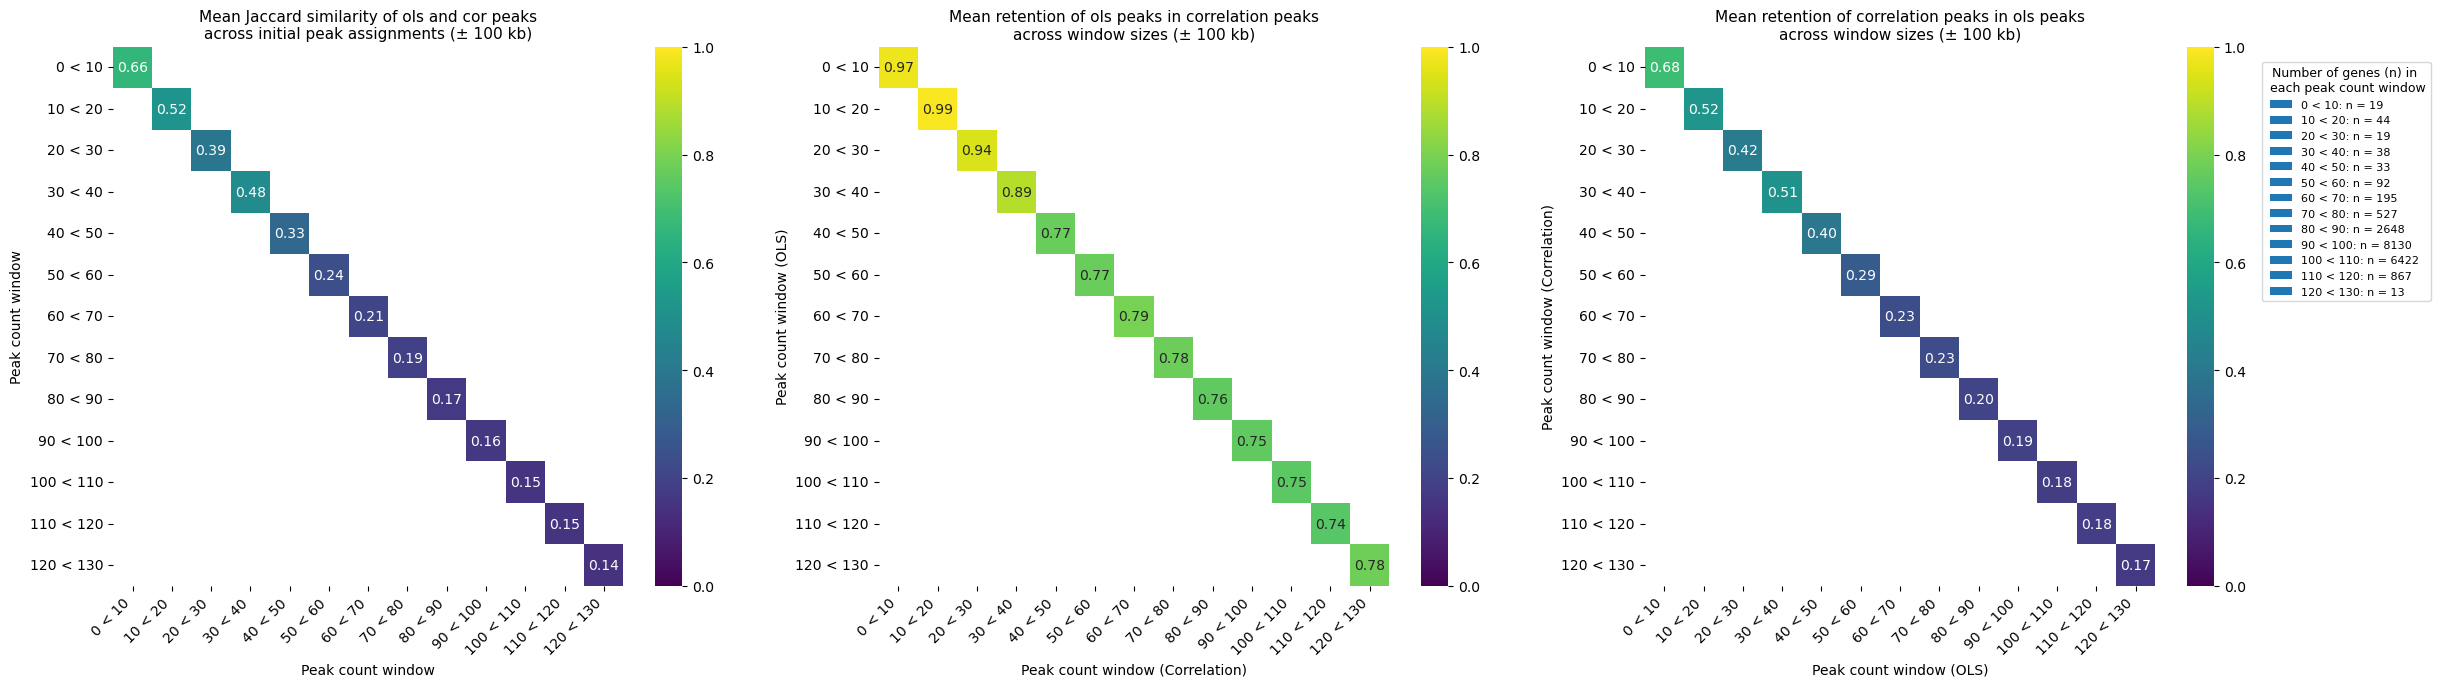

<Figure size 640x480 with 0 Axes>

In [20]:
#defining a function to create annotation strings for the heatmap, including the mean value and the number of genes that contributed to that mean value for each cell in the matrix
def make_annot(matrix, counts):
    annot = matrix.copy().astype(object)
    for w1 in matrix.index:
        for w2 in matrix.columns:
            val = matrix.loc[w1, w2]
            n = counts.loc[w1, w2]
            if pd.isna(val):
                annot.loc[w1, w2] = ""
            else:
                n_int = int(n) if not pd.isna(n) else 0
                annot.loc[w1, w2] = f"{val:.2f}\n(n={n_int})"
    return annot

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
import seaborn as sns

window_labels = ['0 < 10', '10 < 20', '20 < 30', '30 < 40', '40 < 50', '50 < 60', '60 < 70', '70 < 80', '80 < 90', '90 < 100', '100 < 110', '110 < 120', '120 < 130']

# --- counts for each comparison ---
jaccard_counts = jaccard_long.pivot_table(
    index="w1", columns="w2", values="jaccard", aggfunc="count"
).reindex(index=window_labels, columns=window_labels)

retention_counts_oc = retention_long_oc.pivot_table(
    index="w1", columns="w2", values="retention", aggfunc="count"
).reindex(index=window_labels, columns=window_labels)

retention_counts_co = retention_long_co.pivot_table(
    index="w1", columns="w2", values="retention", aggfunc="count"
).reindex(index=window_labels, columns=window_labels)


# --- annotation strings ---
jaccard_annot = make_annot(jaccard_matrix, jaccard_counts)
retention_annot_oc = make_annot(retention_matrix_oc, retention_counts_oc)
retention_annot_co = make_annot(retention_matrix_co, retention_counts_co)

vmin = 0
vmax = 1.0

# --- plot ---
fig, axes = plt.subplots(1, 3, figsize=(28, 7))
#make annotation size smaller
sns.heatmap(jaccard_matrix.astype(float), annot= True, fmt=".2f", cmap="viridis", vmin=vmin, vmax=vmax, ax=axes[0]) #make annotation size smaller
axes[0].set_xticklabels( jaccard_matrix.columns, rotation=45, ha="right")
axes[0].set_xlabel("Peak count window")
axes[0].set_ylabel("Peak count window")
axes[0].set_title("Mean Jaccard similarity of ols and cor peaks\nacross initial peak assignments (± 100 kb)", fontsize=11)

sns.heatmap(retention_matrix_oc.astype(float), annot= True, fmt=".2f", cmap="viridis", vmin=vmin, vmax=vmax, ax=axes[1])
axes[1].set_xticklabels( retention_matrix_oc.columns, rotation=45, ha="right")
axes[1].set_xlabel("Peak count window (Correlation)")
axes[1].set_ylabel("Peak count window (OLS)")
axes[1].set_title("Mean retention of ols peaks in correlation peaks\nacross window sizes (± 100 kb)", fontsize=11 )

sns.heatmap(retention_matrix_co.astype(float), annot= True, fmt=".2f", cmap="viridis", vmin=vmin, vmax=vmax, ax=axes[2])
axes[2].set_xticklabels( retention_matrix_co.columns, rotation=45, ha="right")
axes[2].set_xlabel("Peak count window (OLS)")
axes[2].set_ylabel("Peak count window (Correlation)")
axes[2].set_title("Mean retention of correlation peaks in ols peaks\nacross window sizes (± 100 kb)", fontsize=11)


# Create a custom legend with title number of genes contributing to each cell's mean value, e.g. 0<10: 6 genes, 10<20: 15 genes, etc.
legend_elements = []
for w in window_labels:
    n = jaccard_counts.loc[w, w]  # take the diagonal count as representative for that window size
    legend_elements.append(mpatches.Patch(label=f"{w}: n = { int(n)} "))
legend = plt.legend(handles=legend_elements, title="Number of genes (n) in \n each peak count window", loc="center right", bbox_to_anchor=(1.55, 0.75), fontsize=8, title_fontsize=9)
legend.get_title().set_ha("center")
plt.show()  # make room for the legend
plt.tight_layout()

In [21]:
#aggregate all matrixs into a long dataframe with columns w1, w2, score_type, score_value

#transform the matrices into long format
jaccard_long_df = jaccard_matrix.reset_index().melt(id_vars="w1", var_name="w2", value_name="jaccard")
retention_long_oc_df = retention_matrix_oc.reset_index().melt(id_vars="w1", var_name="w2", value_name="retention_oc")
retention_long_co_df = retention_matrix_co.reset_index().melt(id_vars="w1", var_name="w2", value_name="retention_co")

print(jaccard_long_df.head())
print(retention_long_oc_df.head())
print(retention_long_co_df.head())

#aggregate all long dataframes into a single long dataframe with columns w1, w2, score_type, score_value
jaccard_long_df["score_value"] = jaccard_long_df["jaccard"]
retention_long_oc_df["score_value"] = retention_long_oc_df["retention_oc"]
retention_long_co_df["score_value"] = retention_long_co_df["retention_co"]

jaccard_long_df["score_type"] = "jaccard"
retention_long_oc_df["score_type"] = "retention_oc"
retention_long_co_df["score_type"] = "retention_co"

all_scores_long_df = pd.concat([jaccard_long_df, retention_long_oc_df, retention_long_co_df], ignore_index=True)
all_scores_long_df = all_scores_long_df[["w1", "w2", "score_type", "score_value"]]
all_scores_long_df = all_scores_long_df.dropna(subset=["score_value"])  # drop rows where score_value is NaN
print(all_scores_long_df.head())

print(all_scores_long_df.dtypes)
print(all_scores_long_df["score_value"].dtype)  # check the dtype of score_value column

        w1      w2   jaccard
0   0 < 10  0 < 10  0.657435
1  10 < 20  0 < 10       NaN
2  20 < 30  0 < 10       NaN
3  30 < 40  0 < 10       NaN
4  40 < 50  0 < 10       NaN
        w1      w2  retention_oc
0   0 < 10  0 < 10      0.973684
1  10 < 20  0 < 10           NaN
2  20 < 30  0 < 10           NaN
3  30 < 40  0 < 10           NaN
4  40 < 50  0 < 10           NaN
        w1      w2  retention_co
0   0 < 10  0 < 10      0.683751
1  10 < 20  0 < 10           NaN
2  20 < 30  0 < 10           NaN
3  30 < 40  0 < 10           NaN
4  40 < 50  0 < 10           NaN
         w1       w2 score_type  score_value
0    0 < 10   0 < 10    jaccard     0.657435
14  10 < 20  10 < 20    jaccard     0.518114
28  20 < 30  20 < 30    jaccard     0.391901
42  30 < 40  30 < 40    jaccard     0.478698
56  40 < 50  40 < 50    jaccard     0.334344
w1              object
w2              object
score_type      object
score_value    float64
dtype: object
float64


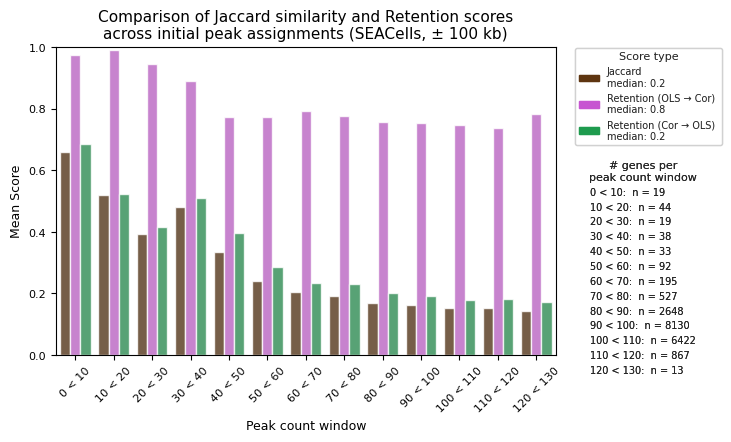

In [22]:
#barplot of the scores from all_scores_long_df, with x-axis = w1, y-axis = score_value, hue = score_type in one plot
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# --- counts per diagonal window ---
jaccard_counts = jaccard_long.pivot_table(
    index="w1", columns="w2", values="jaccard", aggfunc="count"
).reindex(index=window_labels, columns=window_labels)
method_colors = {
    "jaccard": "#5e3510",
    "retention_oc": "#c755d1",
    "retention_co": "#1e9b4e"
}

fig, ax = plt.subplots(figsize=(9, 4))
sns.set_style("whitegrid")
median_scores = all_scores_long_df.groupby(["w1", "score_type"])["score_value"].median().reset_index()
sns.barplot(
    data=all_scores_long_df,
    x="w1", y="score_value",
    hue="score_type",
    palette=method_colors,
    dodge=True, alpha=0.8,
    errorbar=None,
    order=window_labels,
    ax=ax,
)
# 1. Remove seaborn's legend first
ax.get_legend().remove()

# --- score type legend ---
score_handles = [
    mpatches.Patch(color=method_colors["jaccard"],      label=f"Jaccard \nmedian: {median_scores[median_scores['score_type'] == 'jaccard']['score_value'].median():.1f} "),
    mpatches.Patch(color=method_colors["retention_oc"], label=f"Retention (OLS → Cor) \nmedian: {median_scores[median_scores['score_type'] == 'retention_oc']['score_value'].median():.1f}"),
    mpatches.Patch(color=method_colors["retention_co"], label=f"Retention (Cor → OLS) \nmedian: {median_scores[median_scores['score_type'] == 'retention_co']['score_value'].median():.1f}"),
]
score_legend = fig.legend(
    handles=score_handles,
    title="Score type",
    loc="upper right",
    bbox_to_anchor=(0.87, 0.89),
    fontsize=7, title_fontsize=8,
    frameon=True,
)
score_legend.get_title().set_ha("center")
ax.add_artist(score_legend)

# --- gene count legend ---
gene_elements = []
for w in window_labels:
    n = jaccard_counts.loc[w, w] if w in jaccard_counts.index and w in jaccard_counts.columns else 0
    n = 0 if (isinstance(n, float) and np.isnan(n)) else int(n)
    gene_elements.append(
        mpatches.Patch(color="none", label=f"{w}:  n = {n}")
    )

gene_legend = ax.legend(
    handles=gene_elements,
    title="# genes per\npeak count window",
    loc="upper right",
    bbox_to_anchor=(1.3, 0.66),  # below score legend
    fontsize=7, title_fontsize=8,
    frameon=False,
    handlelength=0,
    handleheight=0,
    handletextpad=0,
)
gene_legend.get_title().set_ha("center")
ax.add_artist(gene_legend)

ax.set_xlabel("Peak count window", fontsize=9, fontweight="roman")
ax.set_ylabel("Mean Score", fontsize=9, fontweight="roman")
ax.set_title(
    "Comparison of Jaccard similarity and Retention scores\nacross initial peak assignments (SEACells, ± 100 kb)",
    fontsize=11, fontweight="roman"
)
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", labelsize=8)
plt.ylim(0, 1.0)
plt.subplots_adjust(right=0.68)  # make room on the right for both legends
plt.show()


In [23]:
#how to make counts matrix from long format df
counts_matrix = jaccard_long.pivot_table(
    index="w1", columns="w2", values="jaccard", aggfunc="count"
).reindex(index=window_labels, columns=window_labels)

#how to make mean matrix from long format df
mean_matrix = jaccard_long.pivot_table(
    index="w1", columns="w2", values="jaccard", aggfunc="mean"
).reindex(index=window_labels, columns=window_labels)

In [20]:
#save the results of long format dataframes 
jaccard_long.to_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Overlaps OLS vs Cor/SEACells/jaccard_long_100kb.csv", index=False)
retention_long_oc.to_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Overlaps OLS vs Cor/SEACells/retention_long_oc_100kb.csv", index=False)
retention_long_co.to_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Overlaps OLS vs Cor/SEACells/retention_long_co_100kb.csv", index=False)


In [24]:
#load the dataframes back in to check if they are saved correctly
import pandas as pd
jaccard_long = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Overlaps OLS vs Cor/SEACells/jaccard_long_100kb.csv")
retention_long_oc = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Overlaps OLS vs Cor/SEACells/retention_long_oc_100kb.csv")
retention_long_co = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Overlaps OLS vs Cor/SEACells/retention_long_co_100kb.csv")

In [25]:
print(jaccard_long.head())
retention_long_oc.head()
retention_long_co.head()

       w1      w2               gene   jaccard
0  0 < 10  0 < 10            znf1136  0.375000
1  0 < 10  0 < 10         zgc:174275  0.714286
2  0 < 10  0 < 10             znf973  0.600000
3  0 < 10  0 < 10         zgc:174698  0.750000
4  0 < 10  0 < 10  si:ch211-207e19.2  1.000000


,w1,w2,gene,retention
0,0 < 10,0 < 10,znf1136,0.375000
1,0 < 10,0 < 10,zgc:174275,0.714286
2,0 < 10,0 < 10,znf973,0.600000
3,0 < 10,0 < 10,zgc:174698,0.750000
4,0 < 10,0 < 10,si:ch211-207e19.2,1.000000


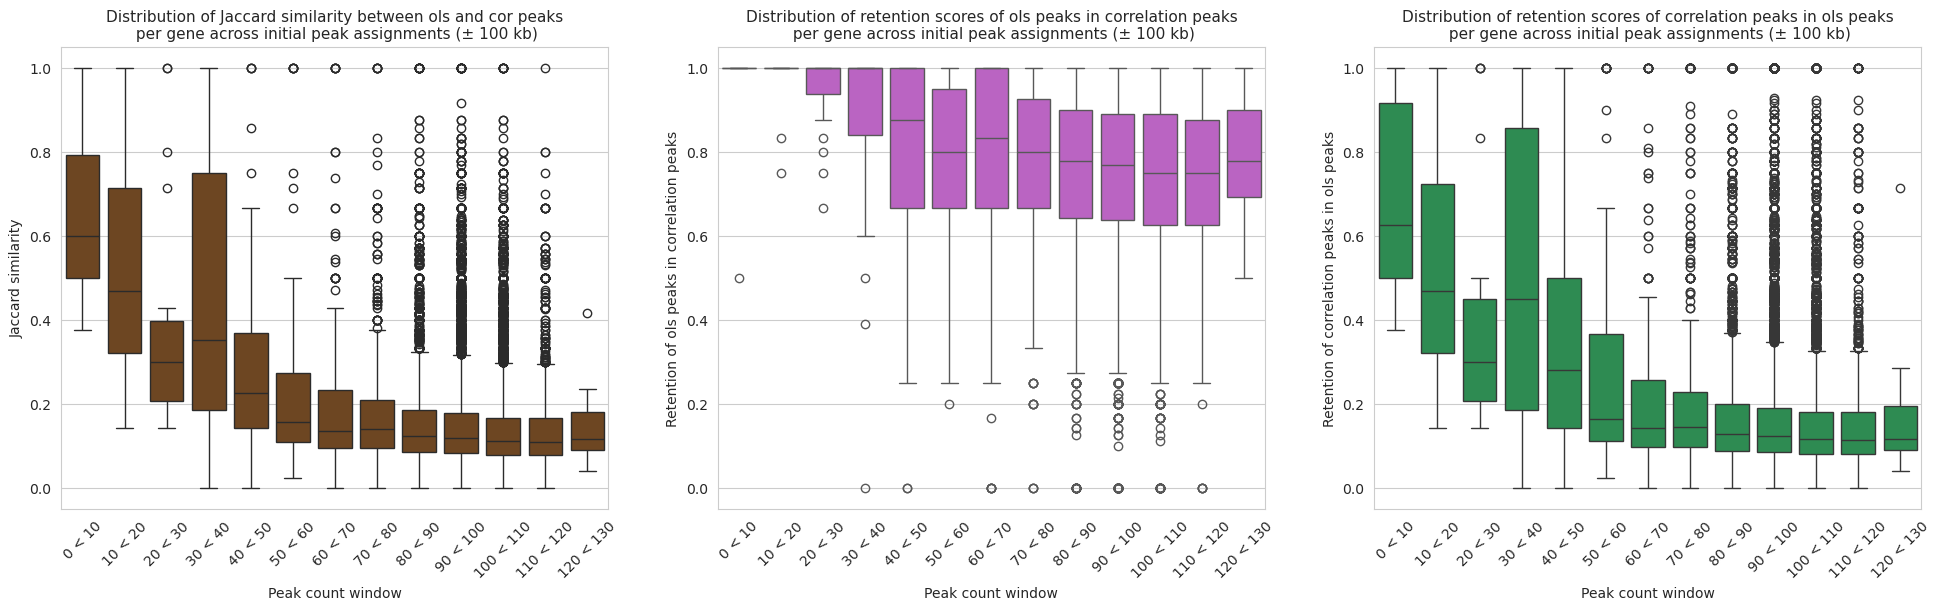

<Figure size 640x480 with 0 Axes>

In [90]:
#plot boxplots of the jaccard similarity and retention values for each pair of window sizes, using the long format dataframes
import matplotlib.pyplot as plt
import seaborn as sns   


fig, axes = plt.subplots(1, 3, figsize=(24, 6))

sns.boxplot(x="w1", y="jaccard", data=jaccard_long, color="#7a4515ff", ax=axes[0])
axes[0].tick_params(axis='x', rotation=45)

#negative log scale the y-axis of the jaccard similarity plot to better visualize the distribution of values, since many values are close to 0
axes[0].set_xlabel("Peak count window")
axes[0].set_ylabel("Jaccard similarity")
axes[0].set_title("Distribution of Jaccard similarity between ols and cor peaks\n per gene across initial peak assignments (± 100 kb)", fontsize=11)

sns.boxplot(x="w1", y="retention", data=retention_long_oc, color= "#c755d1", ax=axes[1])
axes[1].tick_params(axis='x', rotation=45)
#axes[1].set_yscale('log')
axes[1].set_xlabel("Peak count window") 
axes[1].set_ylabel("Retention of ols peaks in correlation peaks")
axes[1].set_title("Distribution of retention scores of ols peaks in correlation peaks\n per gene across initial peak assignments (± 100 kb)", fontsize=11)

sns.boxplot(x="w1", y="retention", data=retention_long_co, color ="#1e9b4e", ax=axes[2])
axes[2].tick_params(axis='x', rotation=45)
#axes[2].set_yscale('log')
axes[2].set_xlabel("Peak count window") 
axes[2].set_ylabel("Retention of correlation peaks in ols peaks")
axes[2].set_title("Distribution of retention scores of correlation peaks in ols peaks\n per gene across initial peak assignments (± 100 kb)", fontsize=11)

plt.show()
plt.tight_layout()


In [91]:
#combine retention dataframes into one long format dataframe for easier plotting
retention_long_oc["comparison"] = "OLS -> Cor"
retention_long_co["comparison"] = "Cor -> OLS"
retention_long_combined = pd.concat([retention_long_oc, retention_long_co], ignore_index=True)
retention_long_combined.head()

,w1,w2,gene,retention,comparison
0,0 < 10,0 < 10,znf1136,1.0,OLS -> Cor
1,0 < 10,0 < 10,zgc:174275,1.0,OLS -> Cor
2,0 < 10,0 < 10,znf973,1.0,OLS -> Cor
3,0 < 10,0 < 10,zgc:174698,1.0,OLS -> Cor
4,0 < 10,0 < 10,si:ch211-207e19.2,1.0,OLS -> Cor


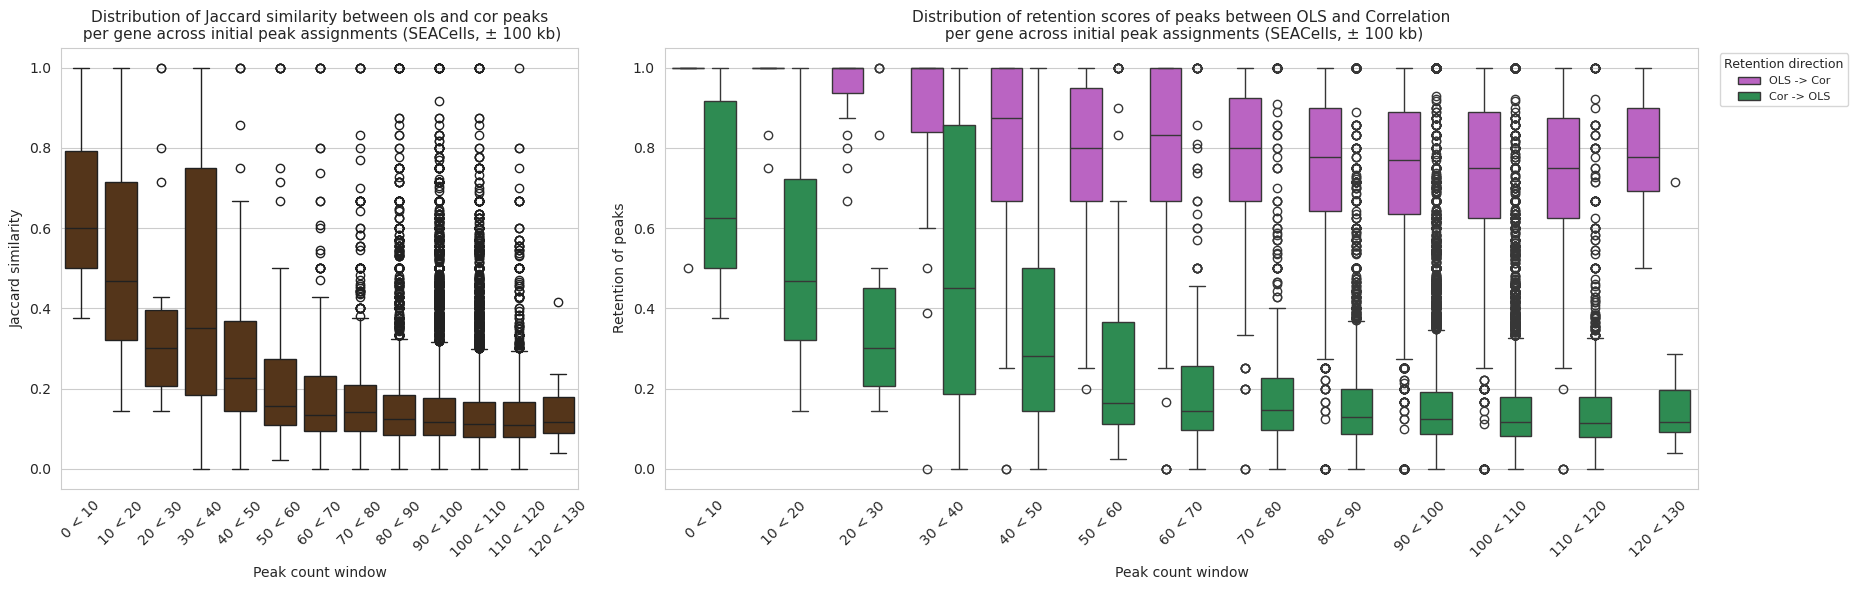

In [93]:
#plot boxplots of the jaccard similarity and retention values for each pair of window sizes, using the long format dataframes
import matplotlib.pyplot as plt
import seaborn as sns   


fig, axes = plt.subplots(1,2, figsize=(18, 6), gridspec_kw={'width_ratios': [1, 2]})

sns.boxplot(x="w1", y="jaccard", data=jaccard_long, color="#5e3410d8", ax=axes[0])
#make the plot quadratic
plt.subplots_adjust(wspace=1.2)
axes[0].tick_params(axis='x', rotation=45)
#negative log scale the y-axis of the jaccard similarity plot to better visualize the distribution of values, since many values are close to 0
#axes[0].set_yscale('log')
axes[0].set_xlabel("Peak count window")
axes[0].set_ylabel("Jaccard similarity")
axes[0].set_title("Distribution of Jaccard similarity between ols and cor peaks\n per gene across initial peak assignments (SEACells, ± 100 kb)", fontsize=11)

method_colors = {"Cor -> OLS": "#1e9b4e", "OLS -> Cor": "#c755d1"}

sns.boxplot(x="w1", y="retention", hue="comparison", data=retention_long_combined, palette=method_colors)
plt.xticks(rotation=45)
plt.xlabel("Peak count window")
plt.ylabel("Retention of peaks")
plt.title("Distribution of retention scores of peaks between OLS and Correlation\n per gene across initial peak assignments (SEACells, ± 100 kb)", fontsize=11)
plt.legend(title="Retention direction", loc="upper right", fontsize=8, title_fontsize=9, bbox_to_anchor=(1.15, 1), frameon=True)
plt.tight_layout()
plt.show()



In [2]:
#load the dataframes back in to check if they are saved correctly
import pandas as pd
jaccard_long = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Overlaps OLS vs Cor/SEACells/jaccard_long_100kb.csv")
retention_long_oc = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Overlaps OLS vs Cor/SEACells/retention_long_oc_100kb.csv")
retention_long_co = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Overlaps OLS vs Cor/SEACells/retention_long_co_100kb.csv")

In [3]:
print(jaccard_long.head())
print(retention_long_oc.head())
print(retention_long_co.head())

       w1      w2               gene   jaccard
0  0 < 10  0 < 10            znf1136  0.375000
1  0 < 10  0 < 10         zgc:174275  0.714286
2  0 < 10  0 < 10             znf973  0.600000
3  0 < 10  0 < 10         zgc:174698  0.750000
4  0 < 10  0 < 10  si:ch211-207e19.2  1.000000
       w1      w2               gene  retention
0  0 < 10  0 < 10            znf1136        1.0
1  0 < 10  0 < 10         zgc:174275        1.0
2  0 < 10  0 < 10             znf973        1.0
3  0 < 10  0 < 10         zgc:174698        1.0
4  0 < 10  0 < 10  si:ch211-207e19.2        1.0
       w1      w2               gene  retention
0  0 < 10  0 < 10            znf1136   0.375000
1  0 < 10  0 < 10         zgc:174275   0.714286
2  0 < 10  0 < 10             znf973   0.600000
3  0 < 10  0 < 10         zgc:174698   0.750000
4  0 < 10  0 < 10  si:ch211-207e19.2   1.000000


In [27]:
#aggregate all matrixs into a long dataframe with columns w1, w2, gene, score_type, score_value

print(jaccard_long.head())
print(retention_long_oc.head())
print(retention_long_co.head())

#aggregate all long dataframes into a single long dataframe with columns w1, w2, score_type, score_value
jaccard_long["score_value"] = jaccard_long["jaccard"]
retention_long_oc["score_value"] = retention_long_oc["retention"]
retention_long_co["score_value"] = retention_long_co["retention"]

jaccard_long["score_type"] = "jaccard"
retention_long_oc["score_type"] = "retention_oc"
retention_long_co["score_type"] = "retention_co"

all_scores_long_df = pd.concat([jaccard_long, retention_long_oc, retention_long_co], ignore_index=True)
all_scores_long_df = all_scores_long_df[["w1", "w2", "score_type", "score_value"]]
all_scores_long_df = all_scores_long_df.dropna(subset=["score_value"])  # drop rows where score_value is NaN
print(all_scores_long_df.head())

print(all_scores_long_df.dtypes)
print(all_scores_long_df["score_value"].dtype)  # check the dtype of score_value column

       w1      w2               gene   jaccard
0  0 < 10  0 < 10            znf1136  0.375000
1  0 < 10  0 < 10         zgc:174275  0.714286
2  0 < 10  0 < 10             znf973  0.600000
3  0 < 10  0 < 10         zgc:174698  0.750000
4  0 < 10  0 < 10  si:ch211-207e19.2  1.000000
       w1      w2               gene  retention
0  0 < 10  0 < 10            znf1136        1.0
1  0 < 10  0 < 10         zgc:174275        1.0
2  0 < 10  0 < 10             znf973        1.0
3  0 < 10  0 < 10         zgc:174698        1.0
4  0 < 10  0 < 10  si:ch211-207e19.2        1.0
       w1      w2               gene  retention
0  0 < 10  0 < 10            znf1136   0.375000
1  0 < 10  0 < 10         zgc:174275   0.714286
2  0 < 10  0 < 10             znf973   0.600000
3  0 < 10  0 < 10         zgc:174698   0.750000
4  0 < 10  0 < 10  si:ch211-207e19.2   1.000000
       w1      w2 score_type  score_value
0  0 < 10  0 < 10    jaccard     0.375000
1  0 < 10  0 < 10    jaccard     0.714286
2  0 < 10  0 < 1

/tmp/ipykernel_1648714/294404455.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_xticklabels(x_labels_with_counts, rotation=45, ha="center")


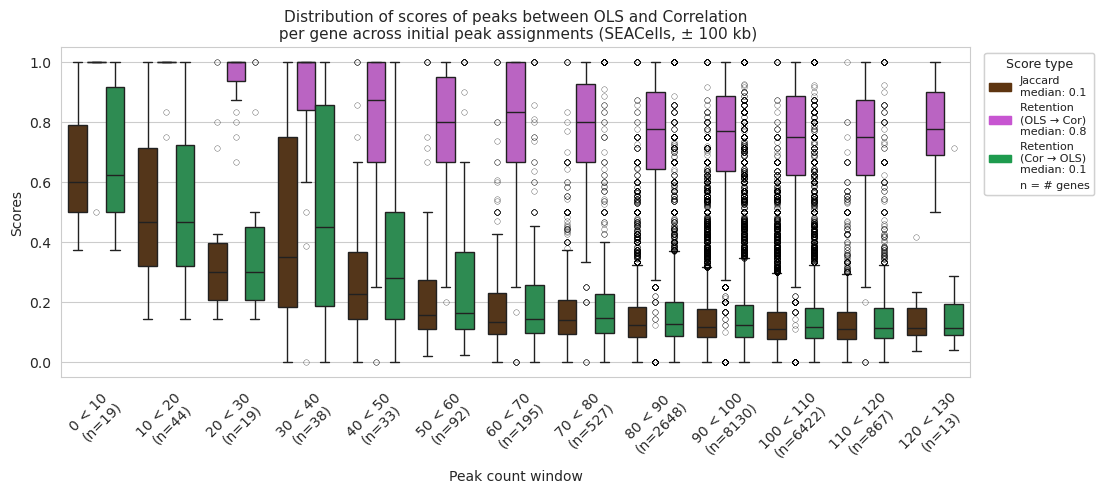

In [54]:

import matplotlib.pyplot as plt
import seaborn as sns   
import matplotlib.patches as mpatches
import numpy as np

# --- counts per diagonal window ---
jaccard_counts = jaccard_long.pivot_table(
    index="w1", columns="w2", values="jaccard", aggfunc="count"
).reindex(index=window_labels, columns=window_labels)
method_colors = {
    "jaccard": "#5e3510",
    "retention_oc": "#c755d1",
    "retention_co": "#1e9b4e"
}
fig, axes = plt.subplots(figsize=(13, 5))

flier_props = dict(
    marker="o",
    markerfacecolor="none",
    markeredgecolor="black",
    markeredgewidth=0.2,
    markersize=4,
    alpha=1,
)

sns.boxplot(x="w1", y="score_value", hue="score_type", data=all_scores_long_df, palette=method_colors, ax= axes, flierprops=flier_props)
sns.set_style("whitegrid")

median_scores = all_scores_long_df.groupby(["w1", "score_type"])["score_value"].median().reset_index()
axes.get_legend().remove()  # Remove seaborn's legend first

# --- score type legend ---
score_handles = [
    mpatches.Patch(color=method_colors["jaccard"],      label=f"Jaccard \nmedian: {median_scores[median_scores['score_type'] == 'jaccard']['score_value'].median():.1f} "),
    mpatches.Patch(color=method_colors["retention_oc"], label=f"Retention \n(OLS → Cor) \nmedian: {median_scores[median_scores['score_type'] == 'retention_oc']['score_value'].median():.1f}"),
    mpatches.Patch(color=method_colors["retention_co"], label=f"Retention \n(Cor → OLS) \nmedian: {median_scores[median_scores['score_type'] == 'retention_co']['score_value'].median():.1f}"),
    mpatches.Patch(color="none", label= f"n = # genes")  # empty patch for spacing
]
score_legend = fig.legend(
    handles=score_handles,
    title="Score type",
    loc="upper right",
    bbox_to_anchor=(0.85,0.88),
    fontsize=8, title_fontsize=9,
    frameon=True,
)
score_legend.get_title().set_ha("center")
axes.add_artist(score_legend)

#add the jaccard_counts to the x-axis labels
x_labels_with_counts = [f"{w} \n(n={int(jaccard_counts.loc[w, w])})" for w in window_labels]
axes.set_xticklabels(x_labels_with_counts, rotation=45, ha="center")  

plt.xticks(rotation=45)
plt.xlabel("Peak count window", fontsize=10, fontweight="roman")
plt.ylabel("Scores", fontsize=10, fontweight="roman")
plt.title("Distribution of scores of peaks between OLS and Correlation\n per gene across initial peak assignments (SEACells, ± 100 kb)", fontsize=11)
plt.tight_layout()
plt.subplots_adjust(right=0.75, bottom=0.22, top=0.88)
plt.savefig("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Overlaps OLS vs Cor/SEACells/score_distribution_boxplot_sc100kb.png", dpi=300, bbox_inches="tight")
plt.show()

## KDE plot to see how the scores are distributed within the windows (peak count)

In [54]:
print(jaccard_long["jaccard"].min(), jaccard_long["jaccard"].max())
print(retention_long_oc["retention"].min(), retention_long_oc["retention"].max())
print(retention_long_co["retention"].min(), retention_long_co["retention"].max())


0.0 1.0
0.0 1.0
0.0 1.0


In [65]:
#rename the columns of the long format dataframes to one standard format for easier plotting
jaccard_long = jaccard_long.rename(columns={"jaccard": "score"})
retention_long_oc = retention_long_oc.rename(columns={"retention": "score"})
retention_long_co = retention_long_co.rename(columns={"retention": "score"})


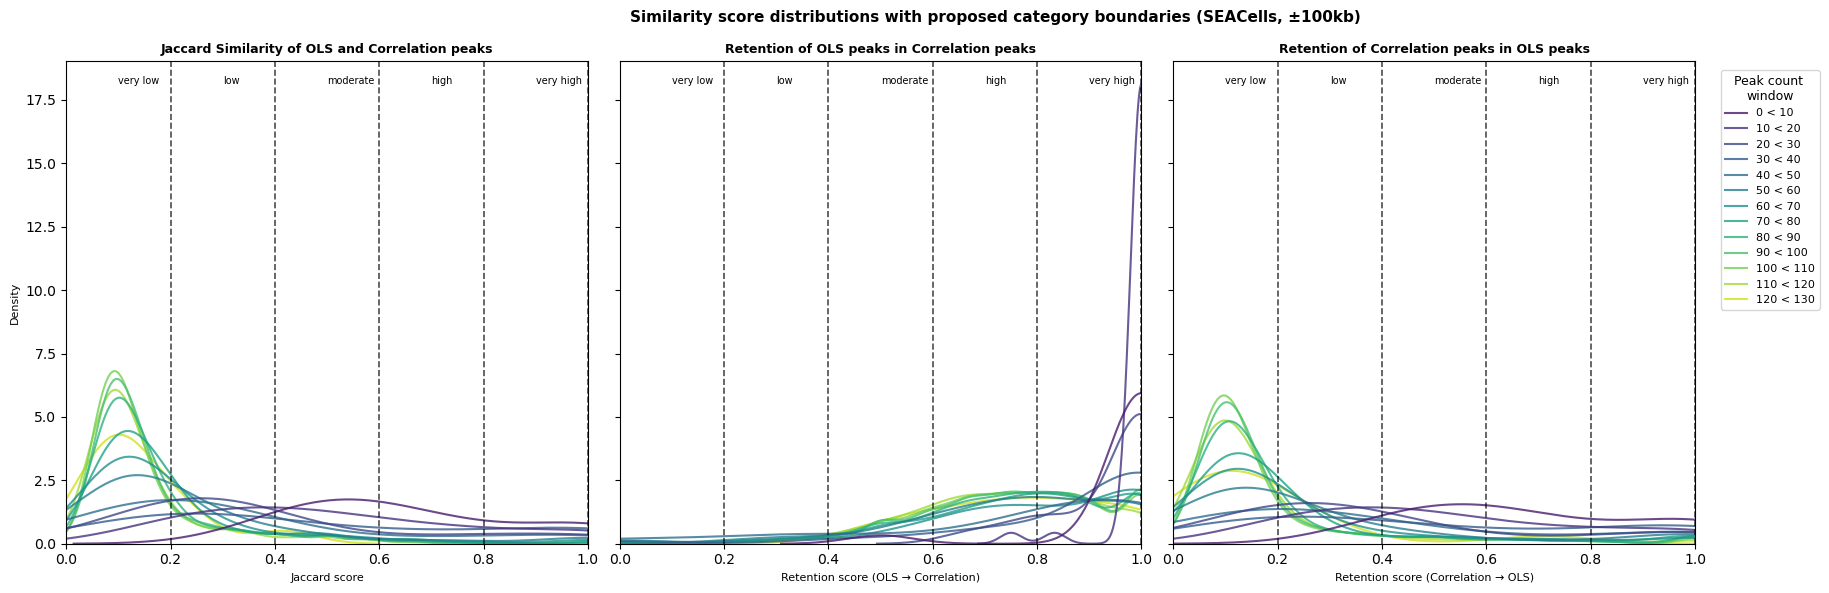

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharex=True, sharey=True)

proposed_cuts = [0.2, 0.4, 0.6, 0.8, 1.0]          # drop 1.0 — no vline needed at axis edge
cut_labels    = ["very low", "low", "moderate", "high", "very high"]

for ax, data, title, xlabel in zip(
    axes,
    [jaccard_long,  retention_long_oc, retention_long_co],
    ["Jaccard Similarity of OLS and Correlation peaks",
     "Retention of OLS peaks in Correlation peaks",
     "Retention of Correlation peaks in OLS peaks"],
    ["Jaccard score",
     "Retention score (OLS → Correlation)",
     "Retention score (Correlation → OLS)"]
):
    sns.kdeplot(
        data=data, x="score", hue="w1",
        palette="viridis", fill=False, common_norm=False,
        alpha=0.8, clip=(0, 1), ax=ax,
        legend=(ax is axes[1])
    )
    for cut, label in zip(proposed_cuts, cut_labels):
        ax.axvline(cut, color="black", linestyle="--", linewidth=1.2, alpha=0.7)

    ax.set_xlim(0, 1)
    ax.set_title(title, fontsize=9, fontweight="bold")
    ax.set_xlabel(xlabel, fontsize=8)
    ax.set_ylabel("Density", fontsize=8)

# Add text labels AFTER loop so ylim is finalised from rendered KDE
for ax in axes:
    ymax = ax.get_ylim()[1]
    for cut, label in zip(proposed_cuts, cut_labels):
        ax.text(
            cut - 0.1, ymax * 0.97, label,
            fontsize=7, va="top", ha="left", color="black",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.6, pad=1)
        )


# Extract handles from right subplot and place a single shared legend outside right edge of figure
# Get the seaborn legend object directly before removing it
sns_legend = axes[1].get_legend()
handles = sns_legend.legend_handles
labels  = [t.get_text() for t in sns_legend.get_texts()]
axes[1].get_legend().remove()

leg =fig.legend(
    handles, labels,
    title="Peak count \nwindow",
    fontsize=8,
    title_fontsize=9,
    loc="center left",
    bbox_to_anchor=(0.86, 0.68),
    frameon=True,
)
#center the title over the two columns of labels
leg.get_title().set_ha("center")

plt.suptitle(
    "Similarity score distributions with proposed category boundaries (SEACells, ±100kb)",
    fontsize=11, fontweight="bold", y=0.98
)
plt.tight_layout()
plt.subplots_adjust(right=0.85)   # make room for legend on the right
plt.show()

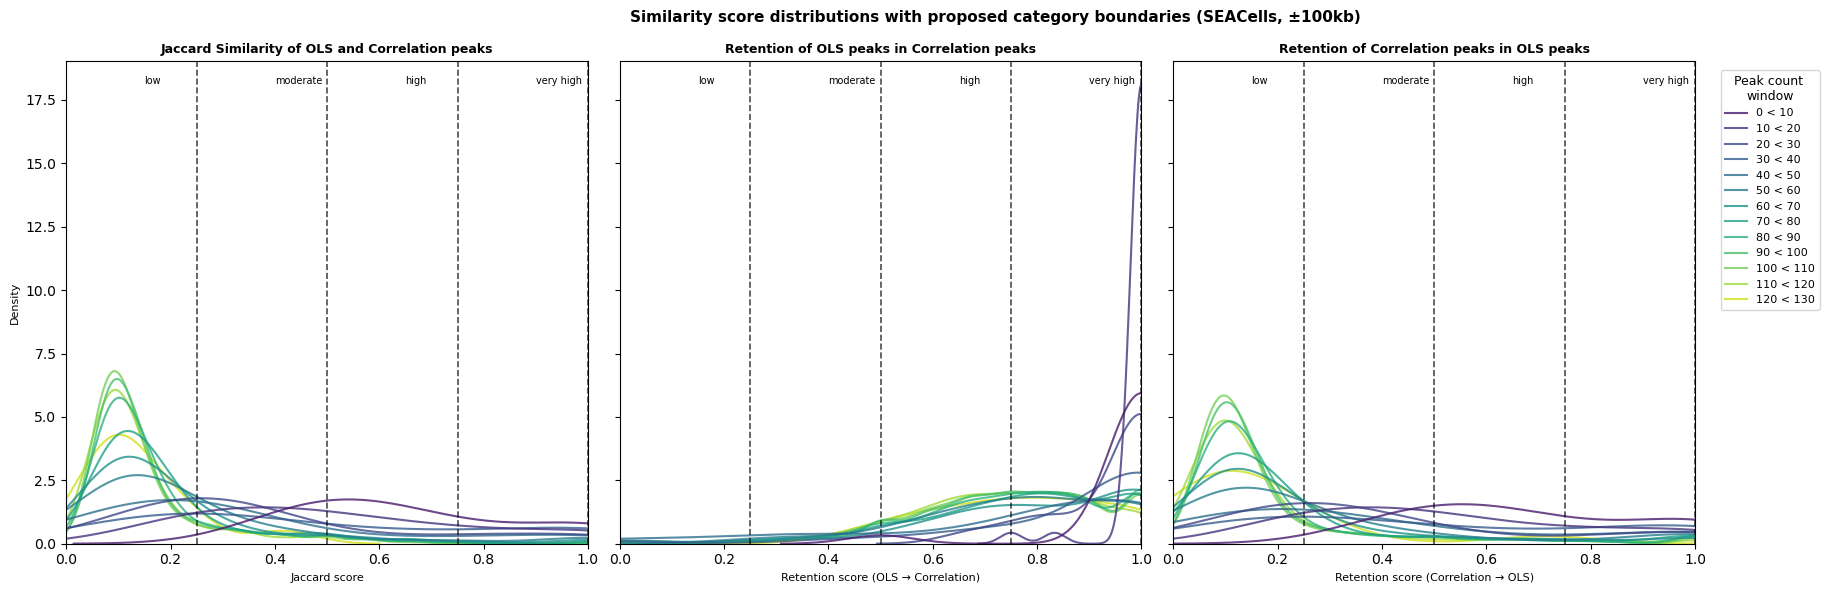

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharex=True, sharey=True)

proposed_cuts = [0.25, 0.5, 0.75,1.0]          # drop 1.0 — no vline needed at axis edge
cut_labels    = ["low", "moderate", "high", "very high"]

for ax, data, title, xlabel in zip(
    axes,
    [jaccard_long,  retention_long_oc, retention_long_co],
    ["Jaccard Similarity of OLS and Correlation peaks",
     "Retention of OLS peaks in Correlation peaks",
     "Retention of Correlation peaks in OLS peaks"],
    ["Jaccard score",
     "Retention score (OLS → Correlation)",
     "Retention score (Correlation → OLS)"]
):
    sns.kdeplot(
        data=data, x="score", hue="w1",
        palette="viridis", fill=False, common_norm=False,
        alpha=0.8, clip=(0, 1), ax=ax,
        legend=(ax is axes[1])
    )
    for cut, label in zip(proposed_cuts, cut_labels):
        ax.axvline(cut, color="black", linestyle="--", linewidth=1.2, alpha=0.7)

    ax.set_xlim(0, 1)
    ax.set_title(title, fontsize=9, fontweight="bold")
    ax.set_xlabel(xlabel, fontsize=8)
    ax.set_ylabel("Density", fontsize=8)

# Add text labels AFTER loop so ylim is finalised from rendered KDE
for ax in axes:
    ymax = ax.get_ylim()[1]
    for cut, label in zip(proposed_cuts, cut_labels):
        ax.text(
            cut - 0.1, ymax * 0.97, label,
            fontsize=7, va="top", ha="left", color="black",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.6, pad=1)
        )


# Extract handles from right subplot and place a single shared legend outside right edge of figure
# Get the seaborn legend object directly before removing it
sns_legend = axes[1].get_legend()
handles = sns_legend.legend_handles
labels  = [t.get_text() for t in sns_legend.get_texts()]
axes[1].get_legend().remove()

leg =fig.legend(
    handles, labels,
    title="Peak count \nwindow",
    fontsize=8,
    title_fontsize=9,
    loc="center left",
    bbox_to_anchor=(0.86, 0.68),
    frameon=True,
)
#center the title over the two columns of labels
leg.get_title().set_ha("center")

plt.suptitle(
    "Similarity score distributions with proposed category boundaries (SEACells, ±100kb)",
    fontsize=11, fontweight="bold", y=0.98
)
plt.tight_layout()
plt.subplots_adjust(right=0.85)   # make room for legend on the right
plt.show()

# Categorize the scores to see better distribution within each assigned peaks window


In [125]:
#load the dataframes back in to check if they are saved correctly
import pandas as pd
jaccard_long = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Overlaps OLS vs Cor/SEACells/jaccard_long_100kb.csv")
retention_long_oc = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Overlaps OLS vs Cor/SEACells/retention_long_oc_100kb.csv")
retention_long_co = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Overlaps OLS vs Cor/SEACells/retention_long_co_100kb.csv")

In [126]:
#retention column to score column for consistency
retention_long_oc = retention_long_oc.rename(columns={"retention": "score"})
retention_long_co = retention_long_co.rename(columns={"retention": "score"})
jaccard_long = jaccard_long.rename(columns={"jaccard": "score"})

In [127]:
#add a category column, by classifying the retention similarity values into three categories: "low" for values < 0.25, "moderate" for values between 0.25 and 0.50, and "high" for values between 0.75 and very high for values > 0.75
def classify_score(value):
    if value < 0.25:
        return "low"
    elif 0.25 <= value < 0.50:
        return "moderate"
    elif 0.50 <= value < 0.75:
        return "high"
    else:
        return "very high"

retention_long_oc["category"] = retention_long_oc["score"].apply(classify_score)
retention_long_co["category"] = retention_long_co["score"].apply(classify_score)
print(retention_long_oc.head())
retention_long_co.head()    

       w1      w2               gene  score   category
0  0 < 10  0 < 10            znf1136    1.0  very high
1  0 < 10  0 < 10         zgc:174275    1.0  very high
2  0 < 10  0 < 10             znf973    1.0  very high
3  0 < 10  0 < 10         zgc:174698    1.0  very high
4  0 < 10  0 < 10  si:ch211-207e19.2    1.0  very high


,w1,w2,gene,score,category
0,0 < 10,0 < 10,znf1136,0.375000,moderate
1,0 < 10,0 < 10,zgc:174275,0.714286,high
2,0 < 10,0 < 10,znf973,0.600000,high
3,0 < 10,0 < 10,zgc:174698,0.750000,very high
4,0 < 10,0 < 10,si:ch211-207e19.2,1.000000,very high


In [128]:
#aggregate the number of significant peaks per gene and category  

agg_retention_oc = (
    retention_long_oc
    .dropna(subset=["gene", "score", "category"]) #
    .groupby(["w1","w2", "category"]) 
    .size()
    .reset_index(name="count")
)

agg_retention_co = (
    retention_long_co
    .dropna(subset=["gene", "score", "category"])
    .groupby(["w1", "w2", "category"])
    .size()
    .reset_index(name="count")
)

print(agg_retention_oc.head())
print(agg_retention_co.head())

          w1         w2   category  count
0     0 < 10     0 < 10       high      1
1     0 < 10     0 < 10  very high     18
2    10 < 20    10 < 20  very high     44
3  100 < 110  100 < 110       high   2455
4  100 < 110  100 < 110        low     53
        w1       w2   category  count
0   0 < 10   0 < 10       high      9
1   0 < 10   0 < 10   moderate      3
2   0 < 10   0 < 10  very high      7
3  10 < 20  10 < 20       high     10
4  10 < 20  10 < 20        low      6


In [129]:
#merge the aggregated dataframes for positive and negative windows to compare the number of significant peaks per gene and category across windows
agg_retention_all = pd.concat(
    [agg_retention_oc.assign(retention="OLS -> Correlation"),
     agg_retention_co.assign(retention="Correlation -> OLS")],
    ignore_index=True
)
agg_retention_all.head()

,w1,w2,category,count,retention
0,0 < 10,0 < 10,high,1,OLS -> Correlation
1,0 < 10,0 < 10,very high,18,OLS -> Correlation
2,10 < 20,10 < 20,very high,44,OLS -> Correlation
3,100 < 110,100 < 110,high,2455,OLS -> Correlation
4,100 < 110,100 < 110,low,53,OLS -> Correlation


In [130]:
#counting the total number of retention scores across windows for both oc and co retention scores
significant_peaks_count = agg_retention_all.groupby(["w1", "w2", "retention"])["count"].sum().reset_index(name="total_count")
significant_peaks_count.head()

,w1,w2,retention,total_count
0,0 < 10,0 < 10,Correlation -> OLS,19
1,0 < 10,0 < 10,OLS -> Correlation,19
2,10 < 20,10 < 20,Correlation -> OLS,44
3,10 < 20,10 < 20,OLS -> Correlation,44
4,100 < 110,100 < 110,Correlation -> OLS,6422


In [131]:
#sanity check: how many genes have 0-10 peaks in both ols and cor datasets, and what is their retention category?
agg_retention_all[(agg_retention_all["retention"] == "oc") & (agg_retention_all["w1"] == "0 < 10") & (agg_retention_all["w2"] == "0 < 10")]

,w1,w2,category,count,retention


In [132]:
#add total_count column to the agg_retention_all dataframe by merging with the significant_peaks_count dataframe on cor_peak_count_window, ols_peak_count_window, and retention columns
agg_retention_all = agg_retention_all.merge(
    significant_peaks_count,
    on=["w1", "w2", "retention"],
    how="left"
)
agg_retention_all.head()

,w1,w2,category,count,retention,total_count
0,0 < 10,0 < 10,high,1,OLS -> Correlation,19
1,0 < 10,0 < 10,very high,18,OLS -> Correlation,19
2,10 < 20,10 < 20,very high,44,OLS -> Correlation,44
3,100 < 110,100 < 110,high,2455,OLS -> Correlation,6422
4,100 < 110,100 < 110,low,53,OLS -> Correlation,6422


In [133]:
#calculate the fraction of categories within one count_window by dividing the total_count by the count of each category in that window and category separately for oc and co retention scores
agg_retention_all["fraction"] = agg_retention_all["count"]/ agg_retention_all["total_count"]


agg_retention_all.head()

,w1,w2,category,count,retention,total_count,fraction
0,0 < 10,0 < 10,high,1,OLS -> Correlation,19,0.052632
1,0 < 10,0 < 10,very high,18,OLS -> Correlation,19,0.947368
2,10 < 20,10 < 20,very high,44,OLS -> Correlation,44,1.000000
3,100 < 110,100 < 110,high,2455,OLS -> Correlation,6422,0.382280
4,100 < 110,100 < 110,low,53,OLS -> Correlation,6422,0.008253


In [134]:
#sort the dataframe by the window_order column to ensure the windows are in the correct order for visualization
agg_retention_all = agg_retention_all.sort_values("w1")
agg_retention_all.tail()

,w1,w2,category,count,retention,total_count,fraction
40,90 < 100,90 < 100,low,78,OLS -> Correlation,8130,0.009594
39,90 < 100,90 < 100,high,3008,OLS -> Correlation,8130,0.369988
91,90 < 100,90 < 100,moderate,776,Correlation -> OLS,8130,0.095449
41,90 < 100,90 < 100,moderate,408,OLS -> Correlation,8130,0.050185
92,90 < 100,90 < 100,very high,340,Correlation -> OLS,8130,0.041820


In [135]:
#sanity check: confirm that the fraction column sums to 1 for each window and category across both directions
fraction_sums = agg_retention_all.groupby(["w1","retention"])["fraction"].sum().reset_index()
print(fraction_sums[fraction_sums["fraction"] != 1.0])

Empty DataFrame
Columns: [w1, retention, fraction]
Index: []


In [136]:
#make window columns categorical with the correct order for visualization
window_order = ['0 < 10', '10 < 20', '20 < 30', '30 < 40', '40 < 50', '50 < 60', '60 < 70', '70 < 80', '80 < 90', '90 < 100', '100 < 110', '110 < 120', '120 < 130']
agg_retention_all["w1"] = pd.Categorical(agg_retention_all["w1"], categories=window_order, ordered=True)
agg_retention_all["w2"] = pd.Categorical(agg_retention_all["w2"], categories=window_order, ordered=True)
agg_retention_all.head()    

,w1,w2,category,count,retention,total_count,fraction
0,0 < 10,0 < 10,high,1,OLS -> Correlation,19,0.052632
1,0 < 10,0 < 10,very high,18,OLS -> Correlation,19,0.947368
45,0 < 10,0 < 10,very high,7,Correlation -> OLS,19,0.368421
44,0 < 10,0 < 10,moderate,3,Correlation -> OLS,19,0.157895
43,0 < 10,0 < 10,high,9,Correlation -> OLS,19,0.473684


In [137]:
jaccard_long["category"] = jaccard_long["score"].apply(classify_score)

#aggregate the number of significant peaks per gene and category  
agg_jaccard = (
    jaccard_long
    .dropna(subset=["gene", "score", "category"])
    .groupby(["w1", "w2", "category"])
    .size()
    .reset_index(name="count")
)
#counting the total number of jaccard scores across windows for each category
significant_peaks_count_jaccard = agg_jaccard.groupby(["w1", "w2"])["count"].sum().reset_index(name="total_count")
print(significant_peaks_count_jaccard.head())


#add total_count column to the agg_jaccard dataframe by merging with the significant_peaks_count dataframe on w1, w2, and category columns
agg_jaccard = agg_jaccard.merge(
    significant_peaks_count_jaccard,
    on=["w1", "w2"],
    how="left"
)
print(agg_jaccard.head())

#calculate the fraction of category counts over the total counts for each window pair in the agg_jaccard dataframe
agg_jaccard["fraction"] = agg_jaccard["count"] / agg_jaccard["total_count"]
print(agg_jaccard.head())

#sanity check: confirm that the fraction column sums to 1 for each window and category across both directions
fraction_sums = agg_jaccard.groupby(["w1", "w2", "category"])["fraction"].sum().reset_index()
print(fraction_sums[fraction_sums["fraction"] != 1.0])

#make window columns categorical with the correct order for visualization
window_order = ['0 < 10', '10 < 20', '20 < 30', '30 < 40', '40 < 50', '50 < 60', '60 < 70', '70 < 80', '80 < 90', '90 < 100', '100 < 110', '110 < 120', '120 < 130']
agg_jaccard["w1"] = pd.Categorical(agg_jaccard["w1"], categories=window_order, ordered=True)
agg_jaccard["w2"] = pd.Categorical(agg_jaccard["w2"], categories=window_order, ordered=True)
agg_jaccard.head()  

          w1         w2  total_count
0     0 < 10     0 < 10           19
1    10 < 20    10 < 20           44
2  100 < 110  100 < 110         6422
3  110 < 120  110 < 120          867
4  120 < 130  120 < 130           13
        w1       w2   category  count  total_count
0   0 < 10   0 < 10       high     10           19
1   0 < 10   0 < 10   moderate      3           19
2   0 < 10   0 < 10  very high      6           19
3  10 < 20  10 < 20       high     11           44
4  10 < 20  10 < 20        low      6           44
        w1       w2   category  count  total_count  fraction
0   0 < 10   0 < 10       high     10           19  0.526316
1   0 < 10   0 < 10   moderate      3           19  0.157895
2   0 < 10   0 < 10  very high      6           19  0.315789
3  10 < 20  10 < 20       high     11           44  0.250000
4  10 < 20  10 < 20        low      6           44  0.136364
           w1         w2   category  fraction
0      0 < 10     0 < 10       high  0.526316
1      0 < 10 

,w1,w2,category,count,total_count,fraction
0,0 < 10,0 < 10,high,10,19,0.526316
1,0 < 10,0 < 10,moderate,3,19,0.157895
2,0 < 10,0 < 10,very high,6,19,0.315789
3,10 < 20,10 < 20,high,11,44,0.250000
4,10 < 20,10 < 20,low,6,44,0.136364


In [138]:
#setting color palette for the retention categories
retention_palette1 = {"very high": "#5e3510", "high": "#5e3410b9", "moderate": "#5e34107b", "low": "#5e341049"}
retention_palette2 = {"very high": "#33729e", "high": "#33729ec5", "moderate": "#65a4d188", "low": "#65a4d142"}
retention_palette3 = {"very high": "#8f9805", "high": "#acbb0d", "moderate": "#c9d179", "low": "#e6f2a2"}


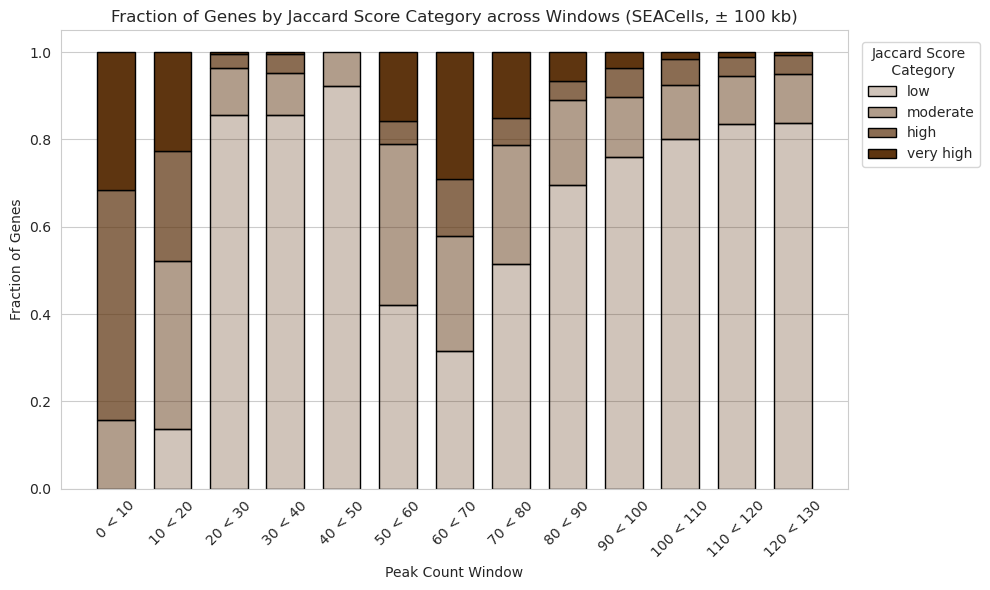

In [157]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

plot_df = agg_jaccard.copy()
window_order = ['0 < 10', '10 < 20', '20 < 30', '30 < 40', '40 < 50', '50 < 60', '60 < 70', '70 < 80', '80 < 90', '90 < 100', '100 < 110', '110 < 120', '120 < 130']
category_order = ["low", "moderate", "high", "very high"]
categories_color_map = retention_palette1

# pull window order from window_order col if present, else fall back to natural sort
if 'window_order' in plot_df.columns:
    windows = (plot_df[['w1', 'window_order']]
               .drop_duplicates()
               .sort_values('window_order')['w1']
               .tolist())
else:
    windows = sorted(plot_df['w1'].unique())


bar_width = 0.2 
offsets = bar_width / 2
x_positions = np.arange(len(windows))*0.3

fig, ax = plt.subplots(figsize=(10, 6))

for j, window in enumerate(windows):
    win_data = plot_df[plot_df['w1'] == window]
    if win_data.empty:
        continue
    # enforce low -> very high stacking order explicitly
    win_data = (win_data.set_index('category')
                .reindex(category_order)
                .dropna(subset=['fraction']))
    total = win_data['fraction'].sum()
    bottom = 0
    x_pos = x_positions[j] + offsets
    for cat, row in win_data.iterrows():
        frac = row['fraction'] / total
        ax.bar(
            x_positions[j], frac, width=bar_width, bottom=bottom,
            color=categories_color_map[cat],
            edgecolor='black',
            
        )
        bottom += frac

ax.set_xticks(x_positions)
ax.set_xticklabels(window_order, rotation=45)
ax.set_xlabel('Peak Count Window')
ax.set_ylabel('Fraction of Genes')
ax.set_title('Fraction of Genes by Jaccard Score Category across Windows (SEACells, ± 100 kb)')

category_handles = [Patch(facecolor=categories_color_map[c], edgecolor='black', label=c)
                    for c in category_order]

legend1 = plt.legend(handles=category_handles, title='Jaccard Score \n Category', loc='upper left', bbox_to_anchor=(1.01, 0.99))
legend1.get_title().set_ha("center")

plt.grid(visible=None, which='major', axis='x')
plt.tight_layout()
plt.show()

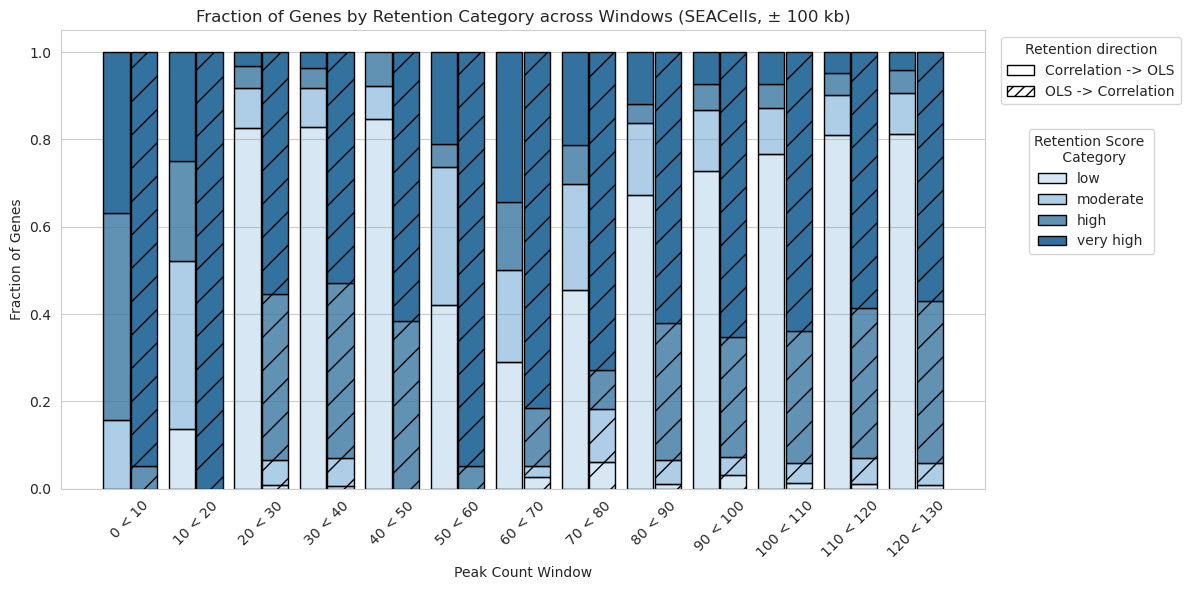

In [156]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

plot_df = agg_retention_all.copy()
window_order = ['0 < 10', '10 < 20', '20 < 30', '30 < 40', '40 < 50', '50 < 60', '60 < 70', '70 < 80', '80 < 90', '90 < 100', '100 < 110', '110 < 120', '120 < 130']
category_order = ["low", "moderate", "high", "very high"]
categories_color_map = retention_palette2

# pull window order from window_order col if present, else fall back to natural sort
if 'window_order' in plot_df.columns:
    windows = (plot_df[['w1', 'window_order']]
               .drop_duplicates()
               .sort_values('window_order')['w1']
               .tolist())
else:
    windows = sorted(plot_df['w1'].unique())

retention_cat = sorted(plot_df['retention'].unique())  # e.g. ['co', 'oc']
hatches = ['', '/']
hatches2 = ['', '///']

bar_width = 0.8 / len(retention_cat)
offsets = (np.arange(len(retention_cat)) - (len(retention_cat) - 1) / 2) * (bar_width + 0.02)
x_positions = np.arange(len(windows))

fig, ax = plt.subplots(figsize=(12, 6))

for i, retention in enumerate(retention_cat):
    ret_data = plot_df[plot_df['retention'] == retention]
    for j, window in enumerate(windows):
        win_data = ret_data[ret_data['w1'] == window]
        if win_data.empty:
            continue
        # enforce low -> very high stacking order explicitly
        win_data = (win_data.set_index('category')
                    .reindex(category_order)
                    .dropna(subset=['fraction']))
        total = win_data['fraction'].sum()
        bottom = 0
        x_pos = x_positions[j] + offsets[i]
        for cat, row in win_data.iterrows():
            frac = row['fraction'] / total
            ax.bar(
                x_pos, frac, width=bar_width, bottom=bottom,
                color=categories_color_map[cat],
                edgecolor='black',
                hatch=hatches[i]
            )
            bottom += frac

ax.set_xticks(x_positions)
ax.set_xticklabels(window_order, rotation=45)
ax.set_xlabel('Peak Count Window')
ax.set_ylabel('Fraction of Genes')
ax.set_title('Fraction of Genes by Retention Category across Windows (SEACells, ± 100 kb)')

category_handles = [Patch(facecolor=categories_color_map[c], edgecolor='black', label=c)
                    for c in category_order]
retention_handles = [Patch(facecolor='white', edgecolor='black', hatch=hatches2[i], label=retention_cat[i])
                     for i in range(len(retention_cat))]

legend1 = ax.legend(handles=category_handles, title='Retention Score \n Category', loc='upper left', bbox_to_anchor=(1.04, 0.8))
ax.add_artist(legend1)
ax.legend(handles=retention_handles, title='Retention direction', loc='upper left', bbox_to_anchor=(1.01, 1))
legend1.get_title().set_ha("center")

plt.grid(visible=None, which='major', axis='x')
plt.subplots_adjust(right=0.85)
plt.tight_layout()
plt.show()